In [1]:
import anndata as ad
PDAC = ad.read_h5ad('/Users/linliu/Library/CloudStorage/Box-Box/linliu/PDAC/ad_PDAC/PDAC_SIMVI.h5ad')

In [6]:
#Build the CCC Tesnor and Decompose it

%reload_ext autoreload
%autoreload 2
import os
import sys
sys.path.append('/Users/linliu/Library/CloudStorage/Box-Box/linliu/Streamline LR/CCC')
from Tensor_Factor import *
from Tensor_Factor_Cor import *
from Pairwise_Comparison import *

#Restart
import anndata as ad
import numpy as np



#PDAC = ad.read_h5ad('C:/Users/linliu/ad_PDAC/PDAC_SIMVI.h5ad')
PDAC = ad.read_h5ad('/Users/linliu/Library/CloudStorage/Box-Box/linliu/PDAC/ad_PDAC/PDAC_SIMVI.h5ad')

In [ ]:
# Add .obs.niche4

# Copy niche3 to niche4, converting to string to avoid categorical assignment issues
PDAC.obs['niche4'] = PDAC.obs['niche3'].astype(str)

# Create a mask for the specified conditions
mask = PDAC.obs['niche'].isin(['Myeloid Niche (Pro-tumor)', 'Myeloid Niche (APC)'])

# Assign niche values to niche4 where the mask is True, using string values
PDAC.obs.loc[mask, 'niche4'] = PDAC.obs.loc[mask, 'niche'].astype(str)

# Convert niche4 back to categorical
PDAC.obs['niche4'] = PDAC.obs['niche4'].astype('category')

In [ ]:
# Assuming PDAC is your AnnData object

# Access the pts dataframe in uns
pts_df = PDAC.uns['rank_genes_groups']['pts']

# Find columns with '/'
bad_cols = [col for col in pts_df.columns if '/' in col]

# Rename them (e.g., replace '/' with '_')
rename_dict = {col: col.replace('/', '_') for col in bad_cols}
pts_df.rename(columns=rename_dict, inplace=True)

# Now save
PDAC.write_h5ad('/Users/linliu/Library/CloudStorage/Box-Box/linliu/PDAC/ad_PDAC/PDAC_SIMVI.h5ad')

In [1]:
#Build the CCC Tesnor and Decompose it

%load_ext autoreload
%autoreload 2
import os
import sys
sys.path.append('/Users/linliu/Library/CloudStorage/Box-Box/linliu/Streamline LR/CCC')
from Tensor_Factor import *
from Pairwise_Comparison import *

PDAC = ad.read_h5ad('/Users/linliu/Library/CloudStorage/Box-Box/linliu/PDAC/ad_PDAC/PDAC_SIMVI.h5ad')

comprehensive_ccc_tensor_analysis(
    adata=PDAC,  # Your AnnData object
    lr_pairs_file="/Users/linliu/Library/CloudStorage/OneDrive-AugustaUniversity/interaction_LR.csv",
    cell_type_col='niche4',
    sample_col='patient',
    tensor_variables=['pN', 'pT', 'OS', 'LVI', 'Grade', 'Apoptosis_score'],
    layer='counts',  # Default: uses layers['counts'] with preprocessing
    n_neighbors=10,
    max_factors=20,
    output_file='ccc_decomposition_results.npz',
    preprocess=True,  # Default
    Tensor_factor_number=14,
)

=== Starting Comprehensive Cell-Cell Communication Analysis ===

1. Preprocessing data...
Using layer 'counts' for expression data
Applying normalization and log transformation...

2. Loading and filtering ligand-receptor pairs...
Valid LR pairs after filtering: 642

3. Computing spatial neighbors...

4. Computing ligand-receptor interactions...
Computing interactions for 642 valid LR pairs...


Processing LR pairs: 100%|██████████| 642/642 [00:47<00:00, 13.65it/s]


LR interaction matrix density: 0.5529%

5. Aggregating data by sample and cell type...
Sanitizing .obs column names...

5.1 Averaging complementary interaction perspectives...


100%|██████████| 49/49 [00:05<00:00,  9.55it/s]


Averaged 5563572 complementary pairs

5.2 Dropping incoming directions after averaging...
Retained 10914 columns (outgoing only)
Post-aggregation refined communication AnnData saved to 'adata_LR_niche4.h5ad'

6. Constructing tensor...
Constructing tensor...
Tensor shape: (17, 17, 642, 49)
Non-zero elements: 1,051,118

7. Using provided tensor factor number: 14
Skipping rank selection and elbow plot generation
Proceeding with rank 14...

8. Performing final decomposition with rank 14...
Running CP for rank 14
reconstruction error=0.7831640839576721
iteration 1, reconstraction error: 0.7692576050758362, decrease = 0.013906478881835938
iteration 2, reconstraction error: 0.7623056769371033, decrease = 0.00695192813873291
iteration 3, reconstraction error: 0.7560504078865051, decrease = 0.0062552690505981445
iteration 4, reconstraction error: 0.7501606345176697, decrease = 0.005889773368835449
iteration 5, reconstraction error: 0.7444708347320557, decrease = 0.005689799785614014
iteration 6

Loading decomposition results from ccc_decomposition_results.npz...
Number of components: 14
Plotting factors (1-based): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Plotting for Factor 1 (internal index 0)
Plotting for Factor 2 (internal index 1)
Plotting for Factor 3 (internal index 2)
Plotting for Factor 4 (internal index 3)
Plotting for Factor 5 (internal index 4)
Plotting for Factor 6 (internal index 5)
Plotting for Factor 7 (internal index 6)
Plotting for Factor 8 (internal index 7)
Plotting for Factor 9 (internal index 8)
Plotting for Factor 10 (internal index 9)
Plotting for Factor 11 (internal index 10)
Plotting for Factor 12 (internal index 11)
Plotting for Factor 13 (internal index 12)
Plotting for Factor 14 (internal index 13)


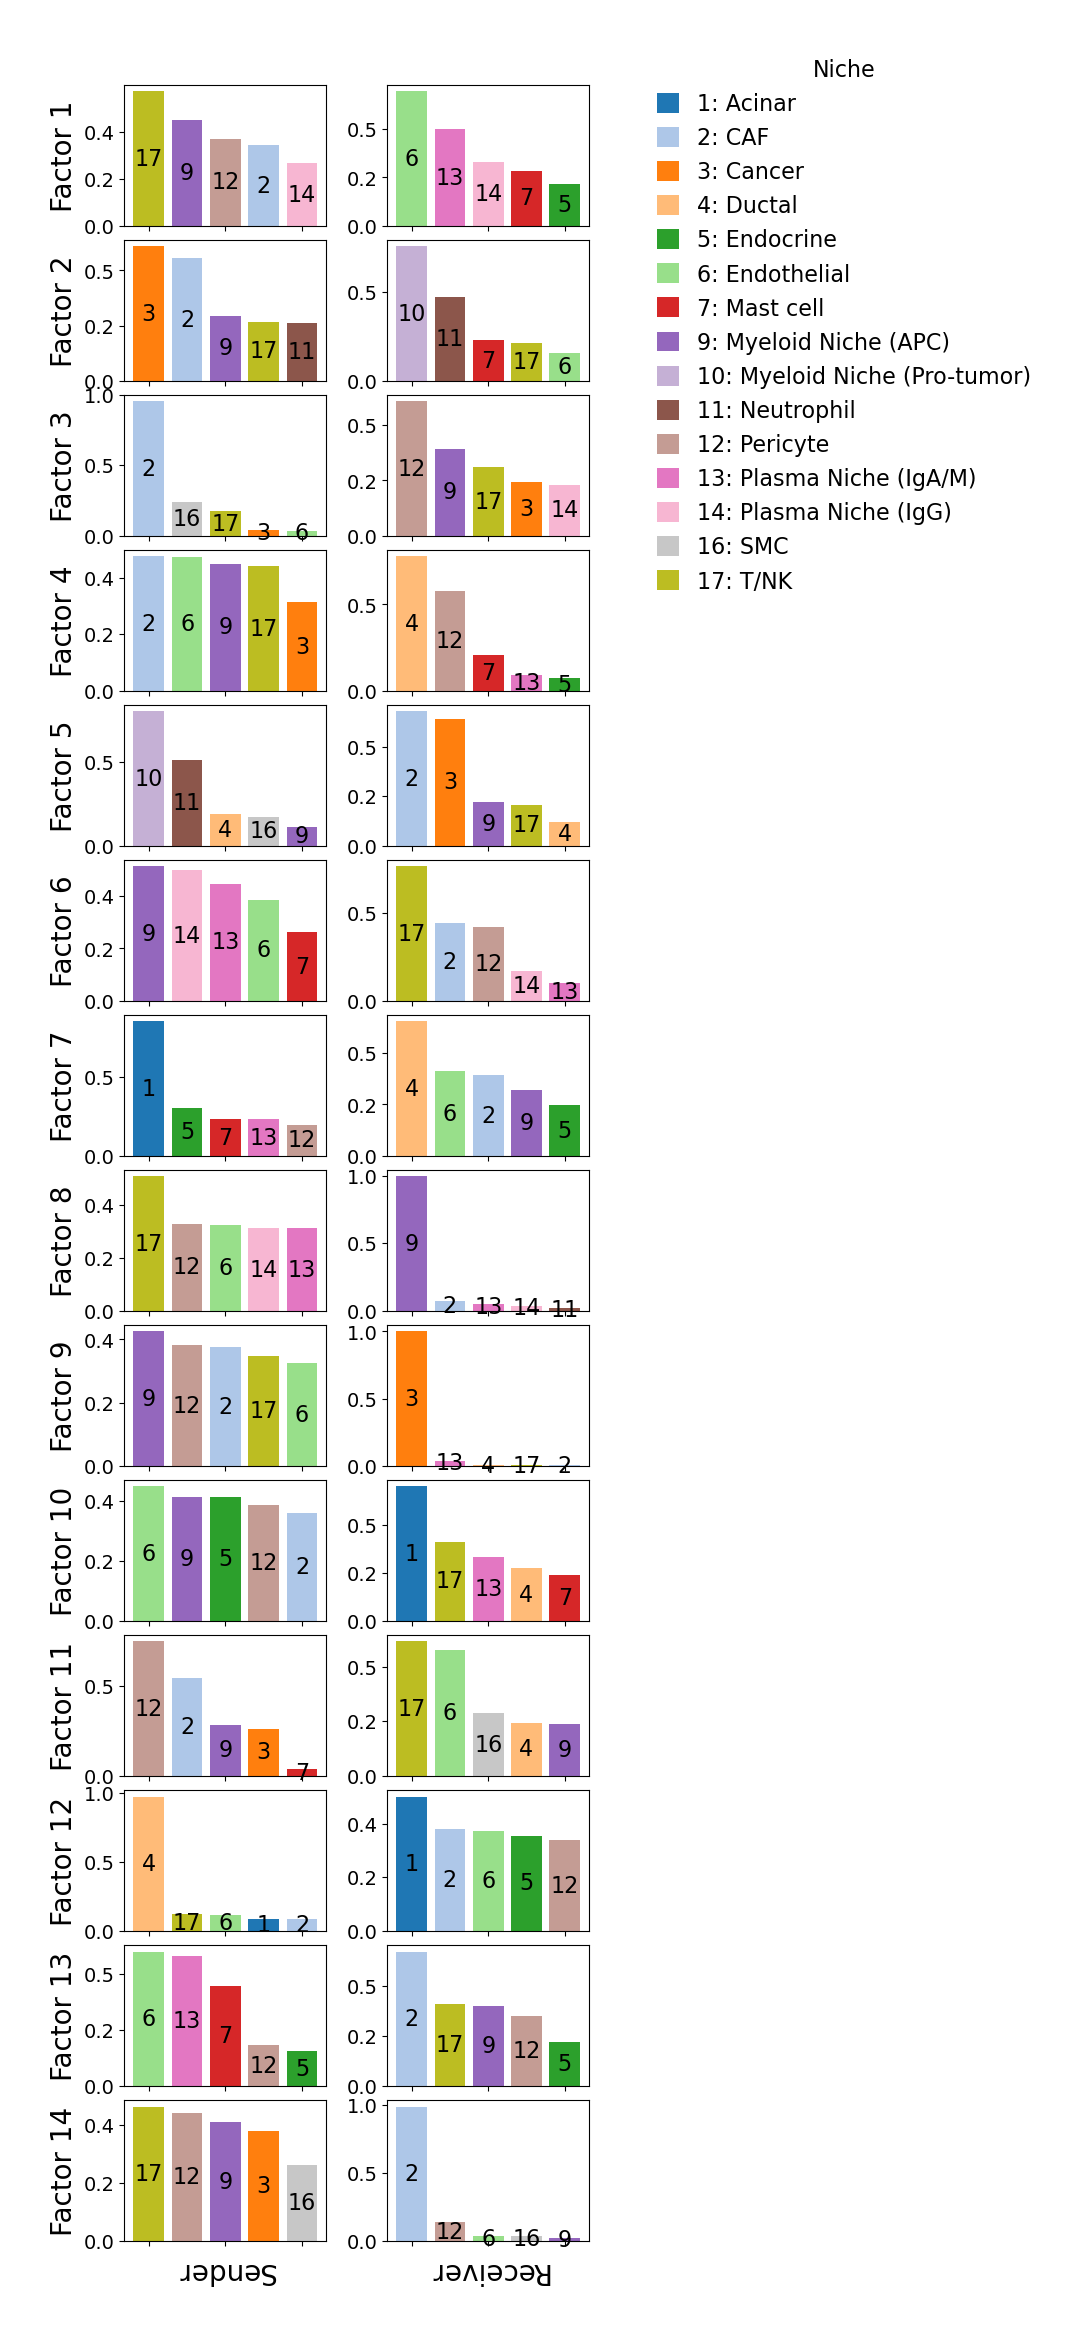

In [10]:
#Plot the results
plot_niche_loadings('ccc_decomposition_results.npz', top_n_loadings=5)

In [36]:
PDAC.obs.OS

B10_1_1          NaN
B10_2_1          NaN
B10_3_1          NaN
B10_4_1          NaN
B10_5_1          NaN
                ... 
TMA32_2519_30    909
TMA32_2521_30    909
TMA32_2522_30    909
TMA32_2523_30    909
TMA32_2524_30    909
Name: OS, Length: 417793, dtype: category
Categories (31, Int64): [101, 115, 133, 145, ..., 2247, 2764, 2952, 4221]

Loading decomposition results from ccc_decomposition_results.npz...


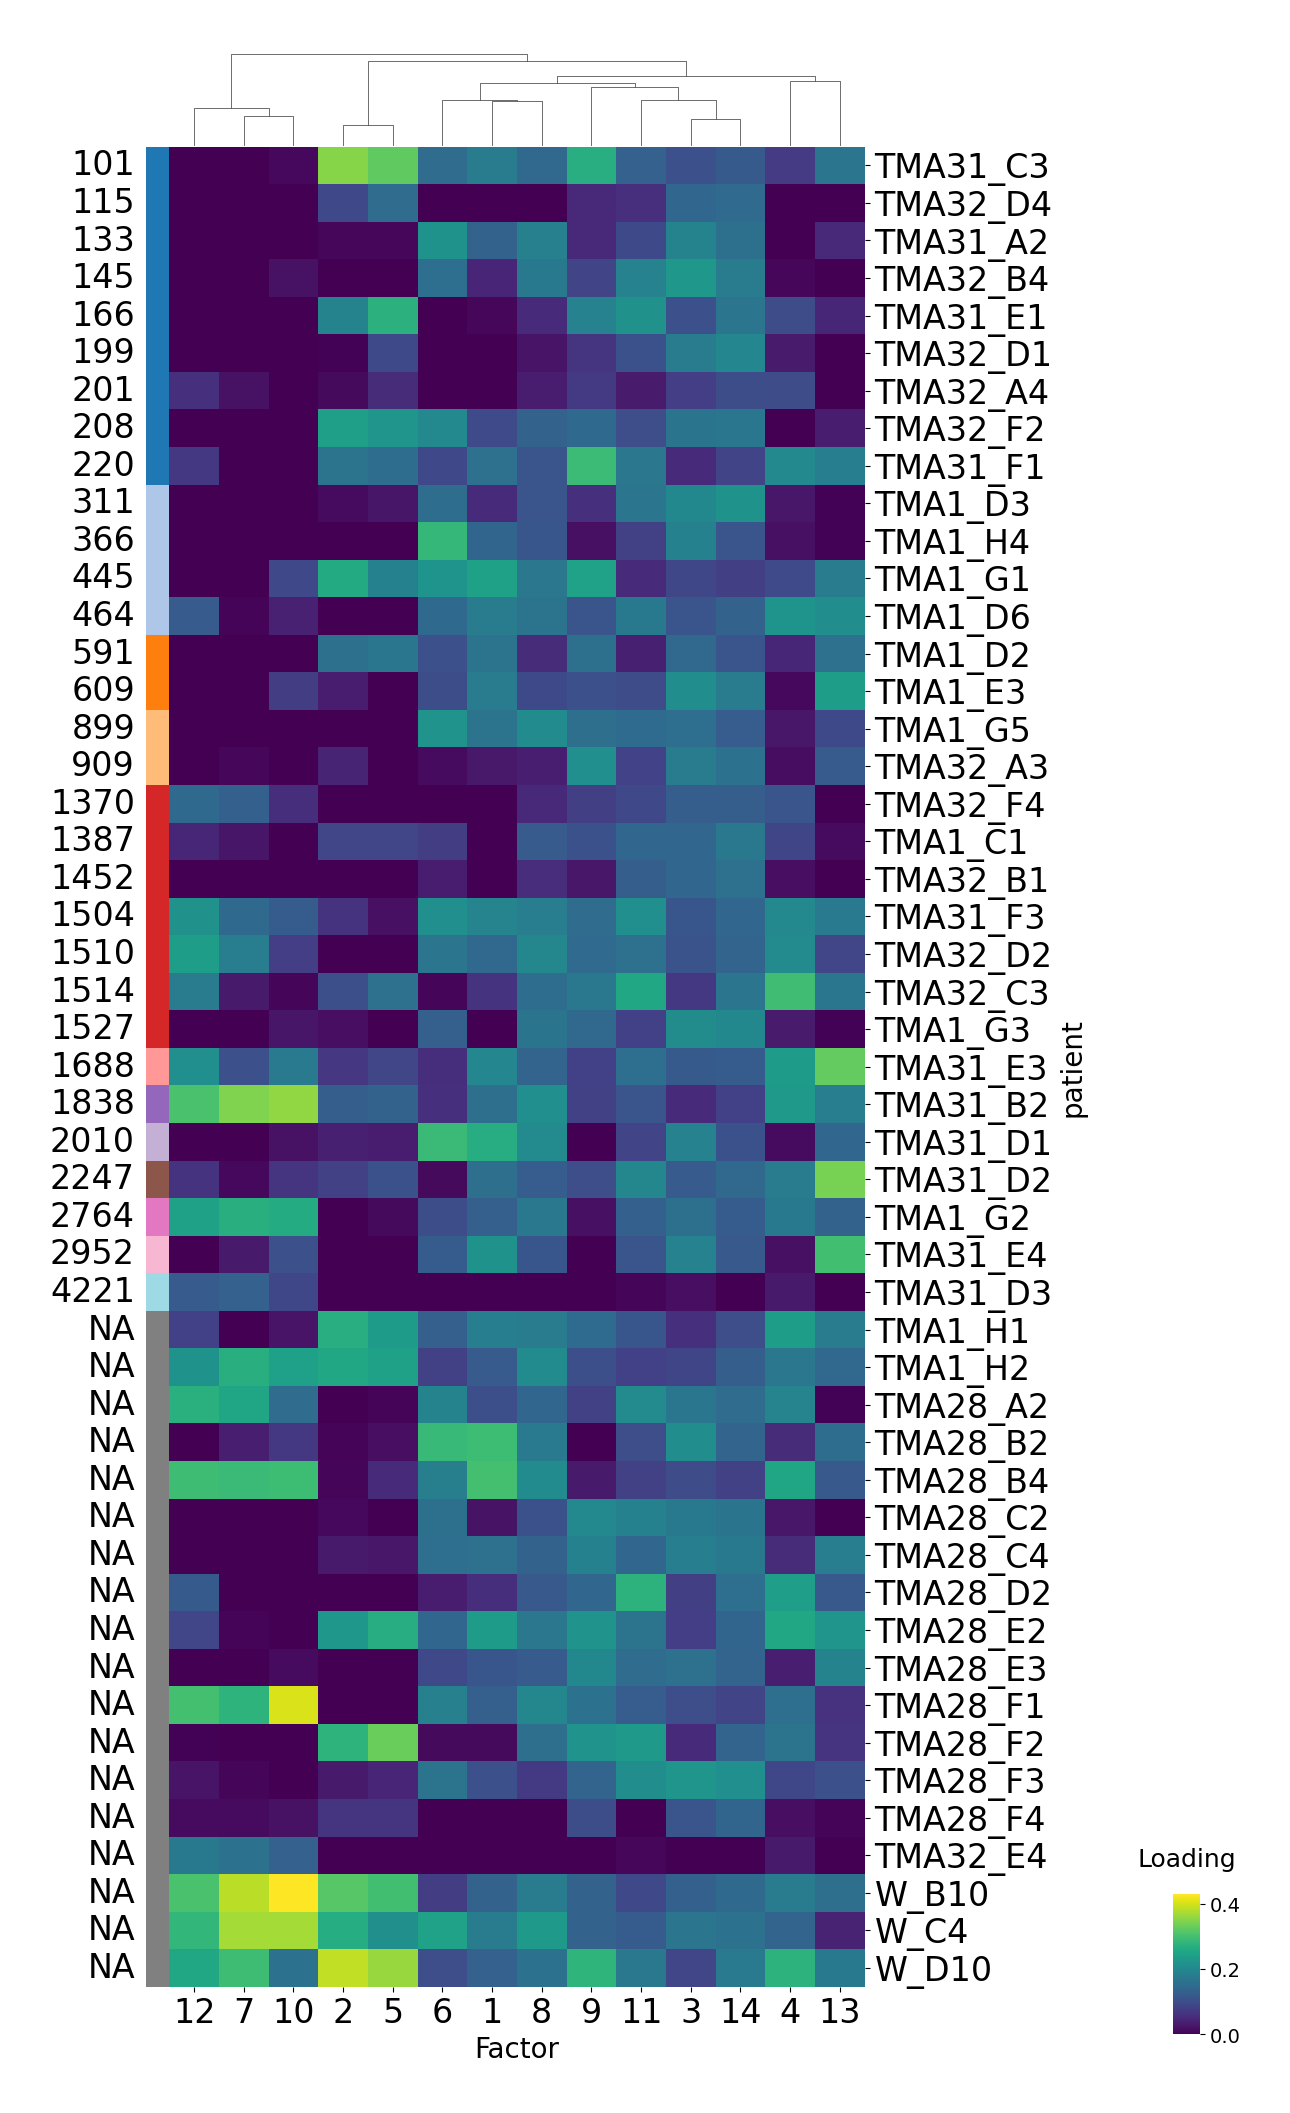

In [4]:
visualize_condition_loadings('ccc_decomposition_results.npz', 
                             'OS', 
                             filter_na=False,
                             figsize=(9,20))

In [14]:
compute_spearman_correlation("ccc_decomposition_results.npz", PDAC, "OS")

Loading decomposition results from ccc_decomposition_results.npz...

Computing Spearman rank correlation between OS and sample loadings...
Factor 1: Spearman correlation = 0.2000, p-value = 2.8070e-01
Factor 2: Spearman correlation = -0.3052, p-value = 9.4960e-02
Factor 3: Spearman correlation = -0.1024, p-value = 5.8351e-01
Factor 4: Spearman correlation = 0.3565, p-value = 4.9036e-02
Factor 5: Spearman correlation = -0.3677, p-value = 4.1820e-02
Factor 6: Spearman correlation = -0.0891, p-value = 6.3356e-01
Factor 7: Spearman correlation = 0.6714, p-value = 3.5571e-05
Factor 8: Spearman correlation = 0.2335, p-value = 2.0622e-01
Factor 9: Spearman correlation = -0.2880, p-value = 1.1613e-01
Factor 10: Spearman correlation = 0.6810, p-value = 2.4761e-05
Factor 11: Spearman correlation = 0.0323, p-value = 8.6323e-01
Factor 12: Spearman correlation = 0.5661, p-value = 9.0118e-04
Factor 13: Spearman correlation = 0.3218, p-value = 7.7526e-02
Factor 14: Spearman correlation = -0.2621, p-v

In [7]:
#Read the CCC AnnData (Intermediate file saved during the tensor construction)
adata_CCC = ad.read_h5ad("adata_LR_niche4.h5ad")
adata_CCC

AnnData object with n_obs × n_vars = 674 × 10914
    obs: 'patient', 'niche4', 'pN', 'pT', 'OS', 'LVI', 'Grade', 'Apoptosis_score'
    uns: 'log1p'

In [12]:
adata_CCC.obs.index

Index(['W_B10|Acinar', 'W_B10|CAF', 'W_B10|Cancer', 'W_B10|Ductal',
       'W_B10|Endocrine', 'W_B10|Endothelial', 'W_B10|Mast cell',
       'W_B10|Myeloid Niche (APC)', 'W_B10|Myeloid Niche (Pro-tumor)',
       'W_B10|Neutrophil',
       ...
       'TMA32_F4|Ductal', 'TMA32_F4|Endocrine', 'TMA32_F4|Endothelial',
       'TMA32_F4|Mast cell', 'TMA32_F4|Myeloid Niche (APC)',
       'TMA32_F4|Neutrophil', 'TMA32_F4|Pericyte', 'TMA32_F4|Plasma cell',
       'TMA32_F4|SMC', 'TMA32_F4|T/NK'],
      dtype='object', length=674)

=== SCENARIO 1: CELL TYPE COMPARISON ===

--- Myeloid Niche (Pro-tumor) vs Myeloid Niche (APC) ---
Creating plot centered on Myeloid Niche (Pro-tumor)
Cell type comparison: Myeloid Niche (Pro-tumor) vs Myeloid Niche (APC) (outgoing):
  Myeloid Niche (Pro-tumor): 32 samples
  Myeloid Niche (APC): 46 samples
  Results: 1 upregulated, 12 downregulated (11 significant)
Cell type comparison: Myeloid Niche (Pro-tumor) vs Myeloid Niche (APC) (incoming):
  Myeloid Niche (Pro-tumor): 32 samples
  Myeloid Niche (APC): 46 samples
  Results: 0 upregulated, 13 downregulated (12 significant)


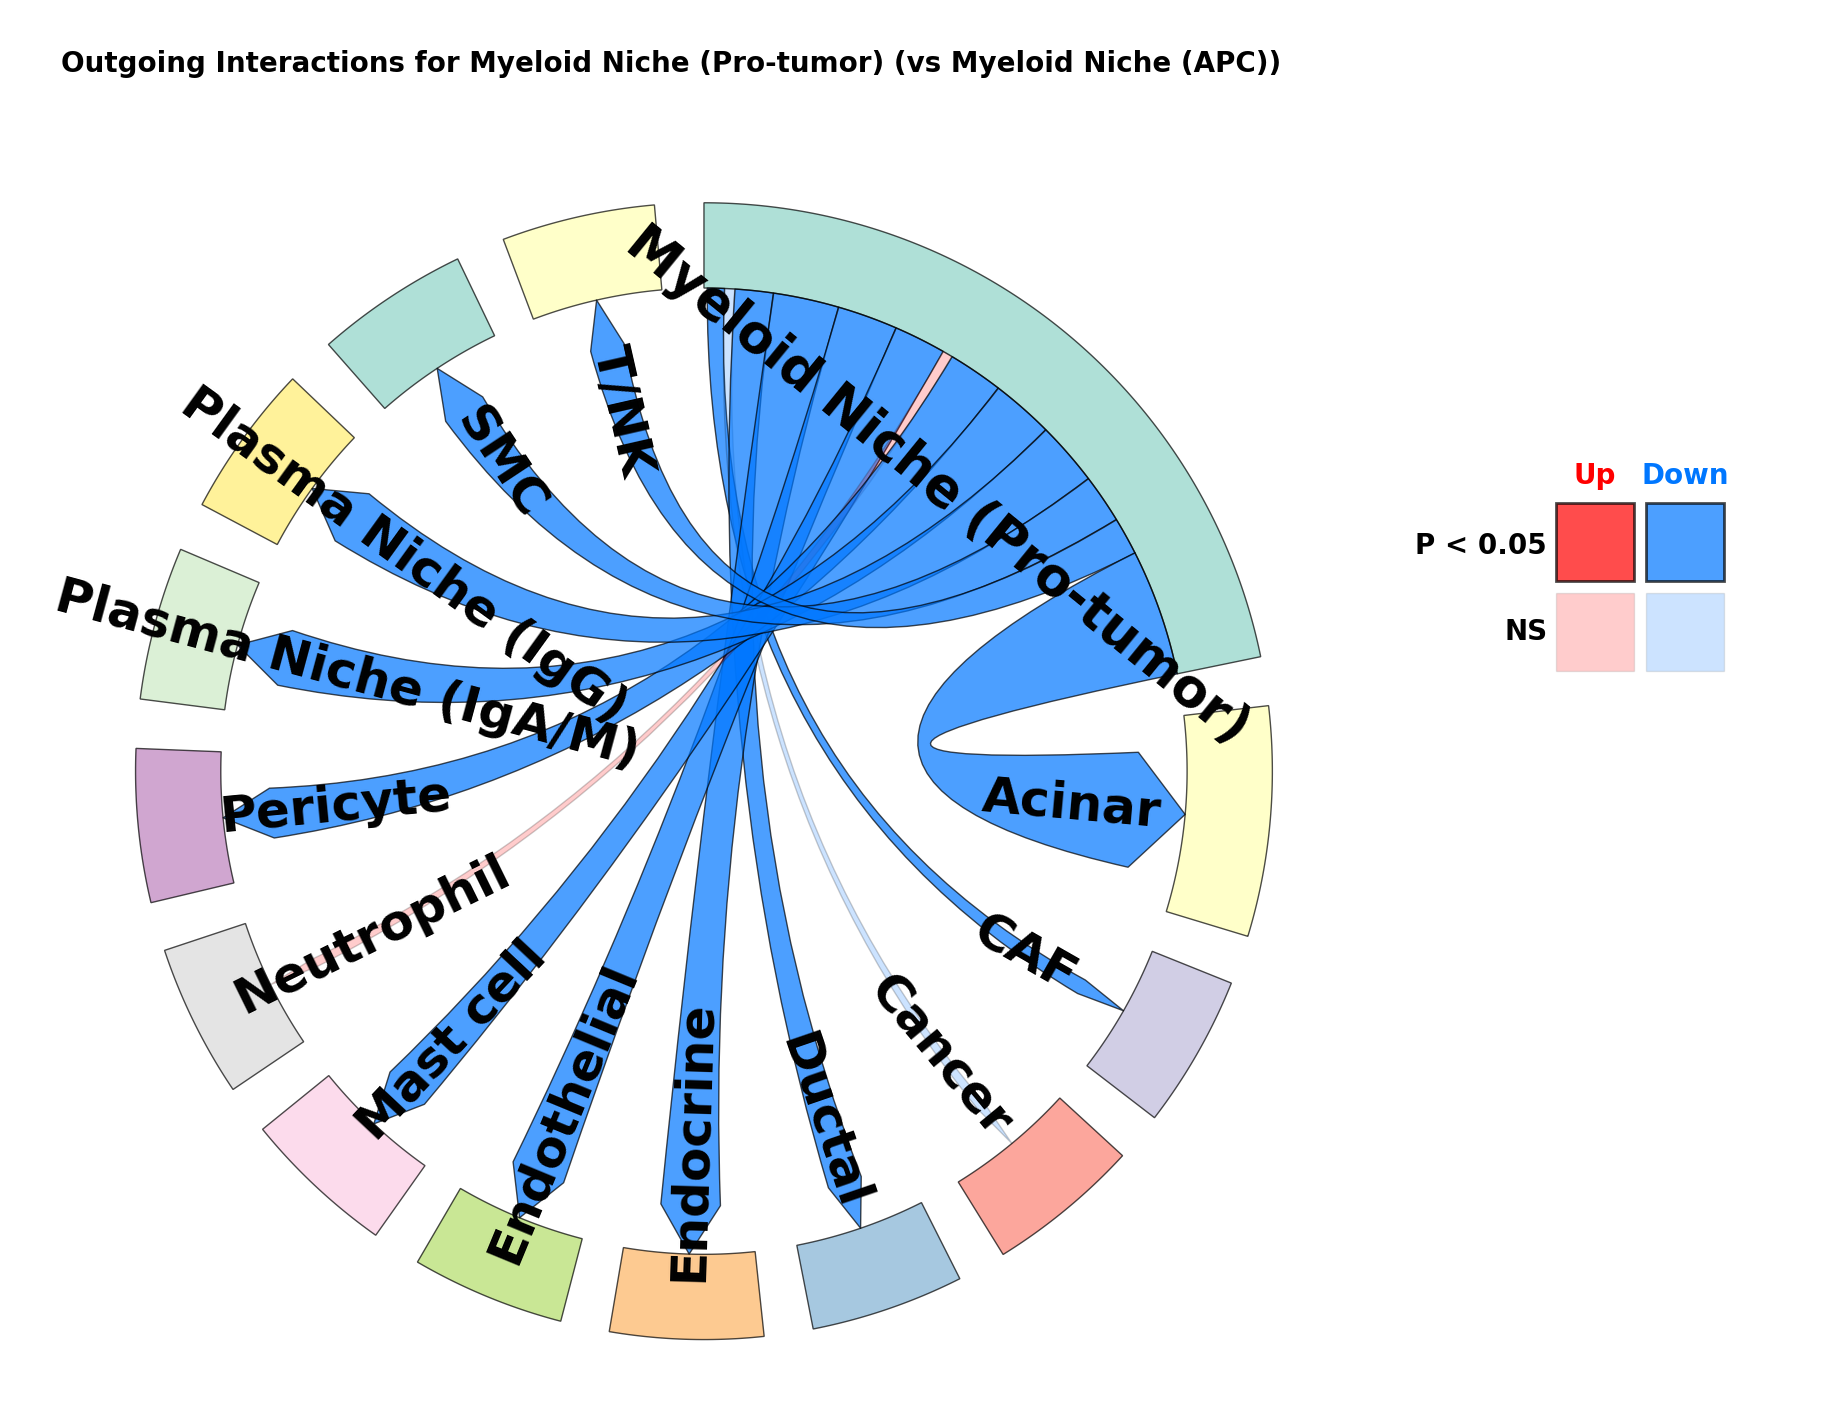

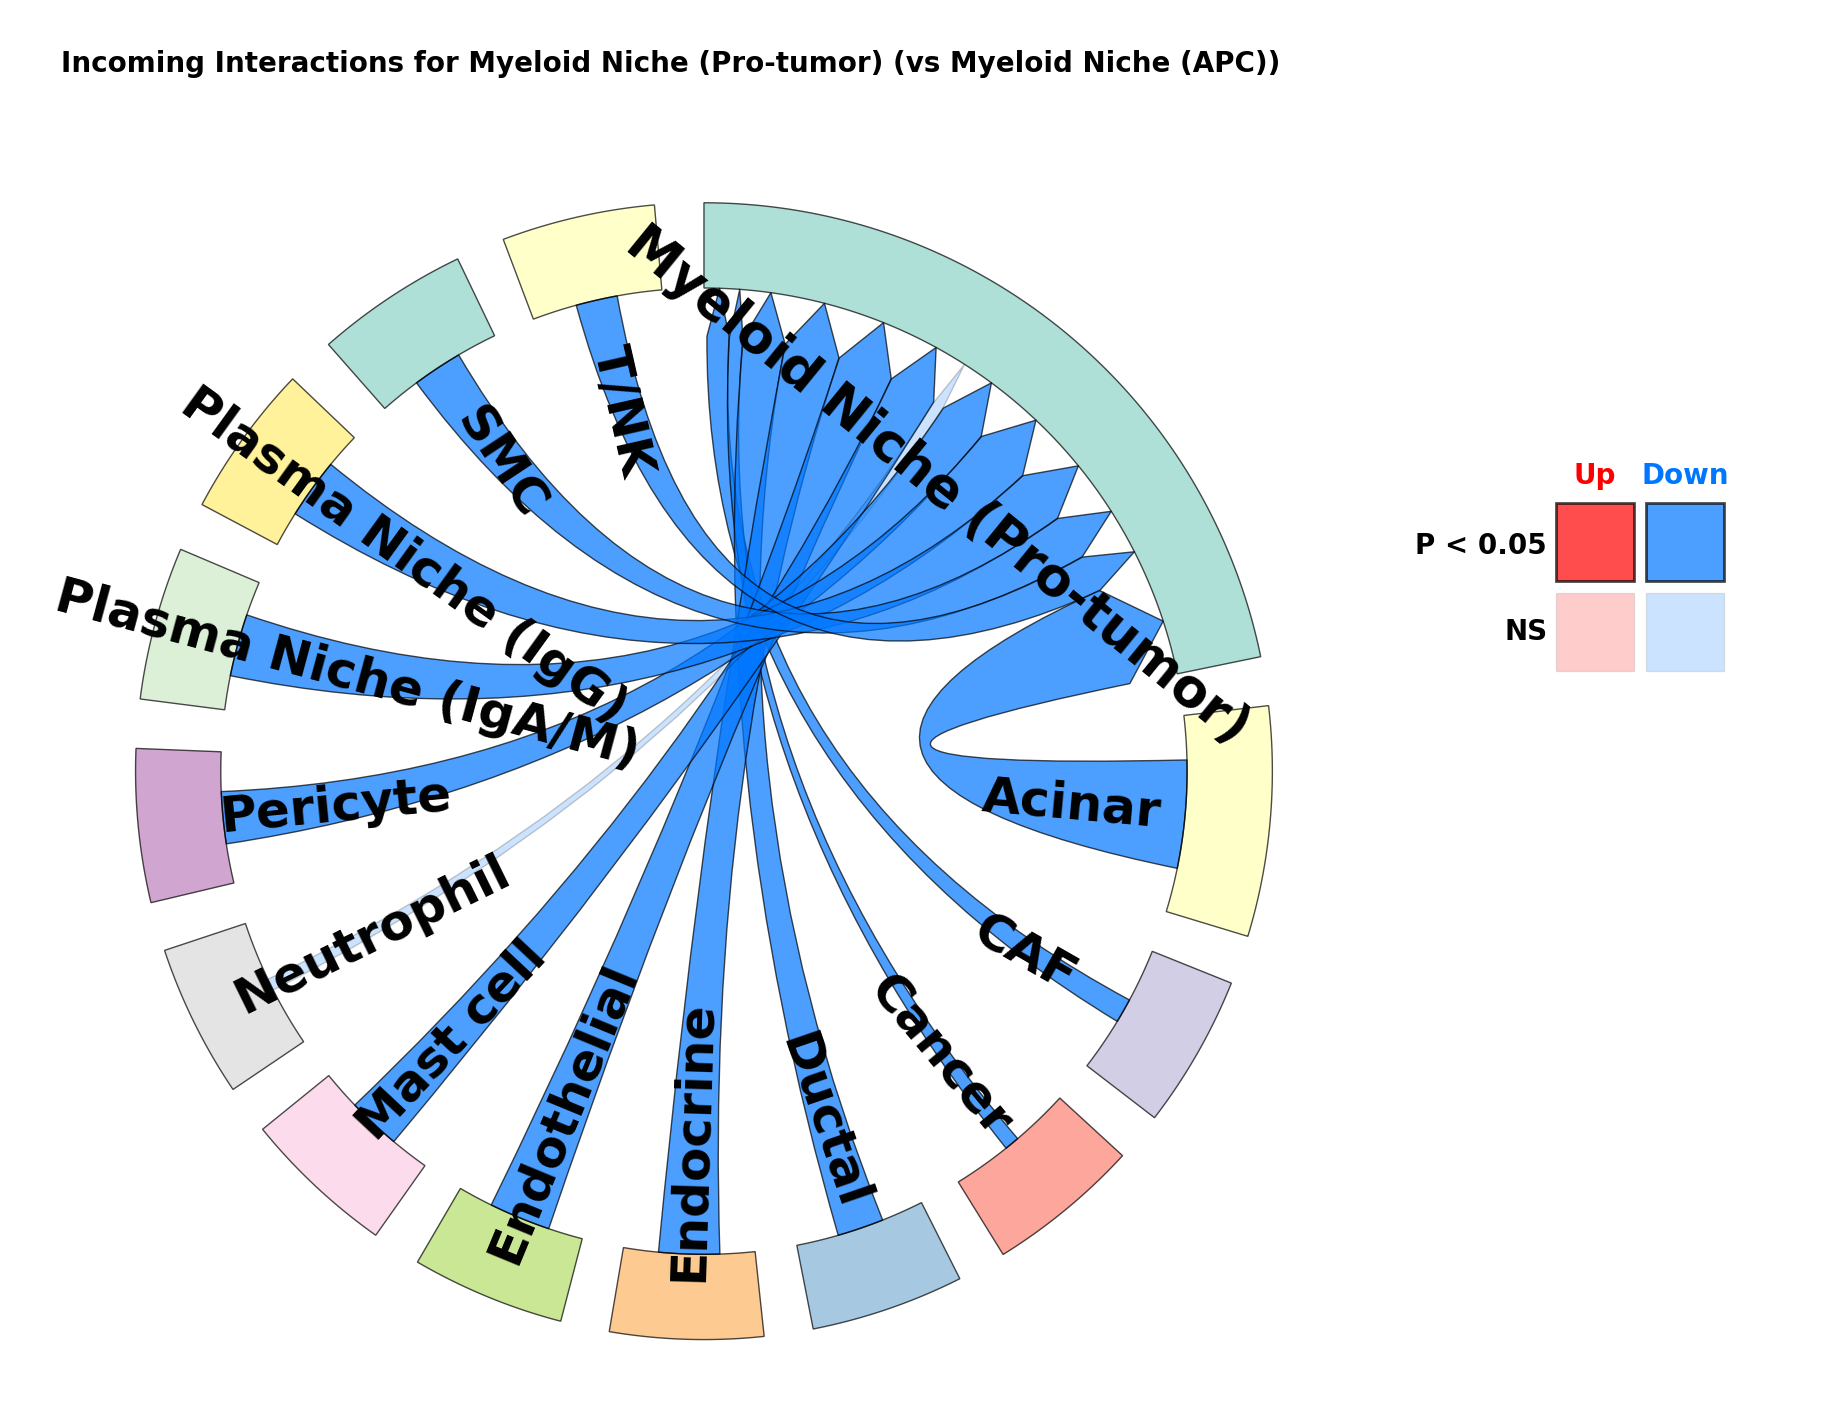

Creating plot centered on Myeloid Niche (APC)
Cell type comparison: Myeloid Niche (APC) vs Myeloid Niche (Pro-tumor) (outgoing):
  Myeloid Niche (APC): 46 samples
  Myeloid Niche (Pro-tumor): 32 samples
  Results: 12 upregulated, 1 downregulated (11 significant)
Cell type comparison: Myeloid Niche (APC) vs Myeloid Niche (Pro-tumor) (incoming):
  Myeloid Niche (APC): 46 samples
  Myeloid Niche (Pro-tumor): 32 samples
  Results: 13 upregulated, 0 downregulated (12 significant)


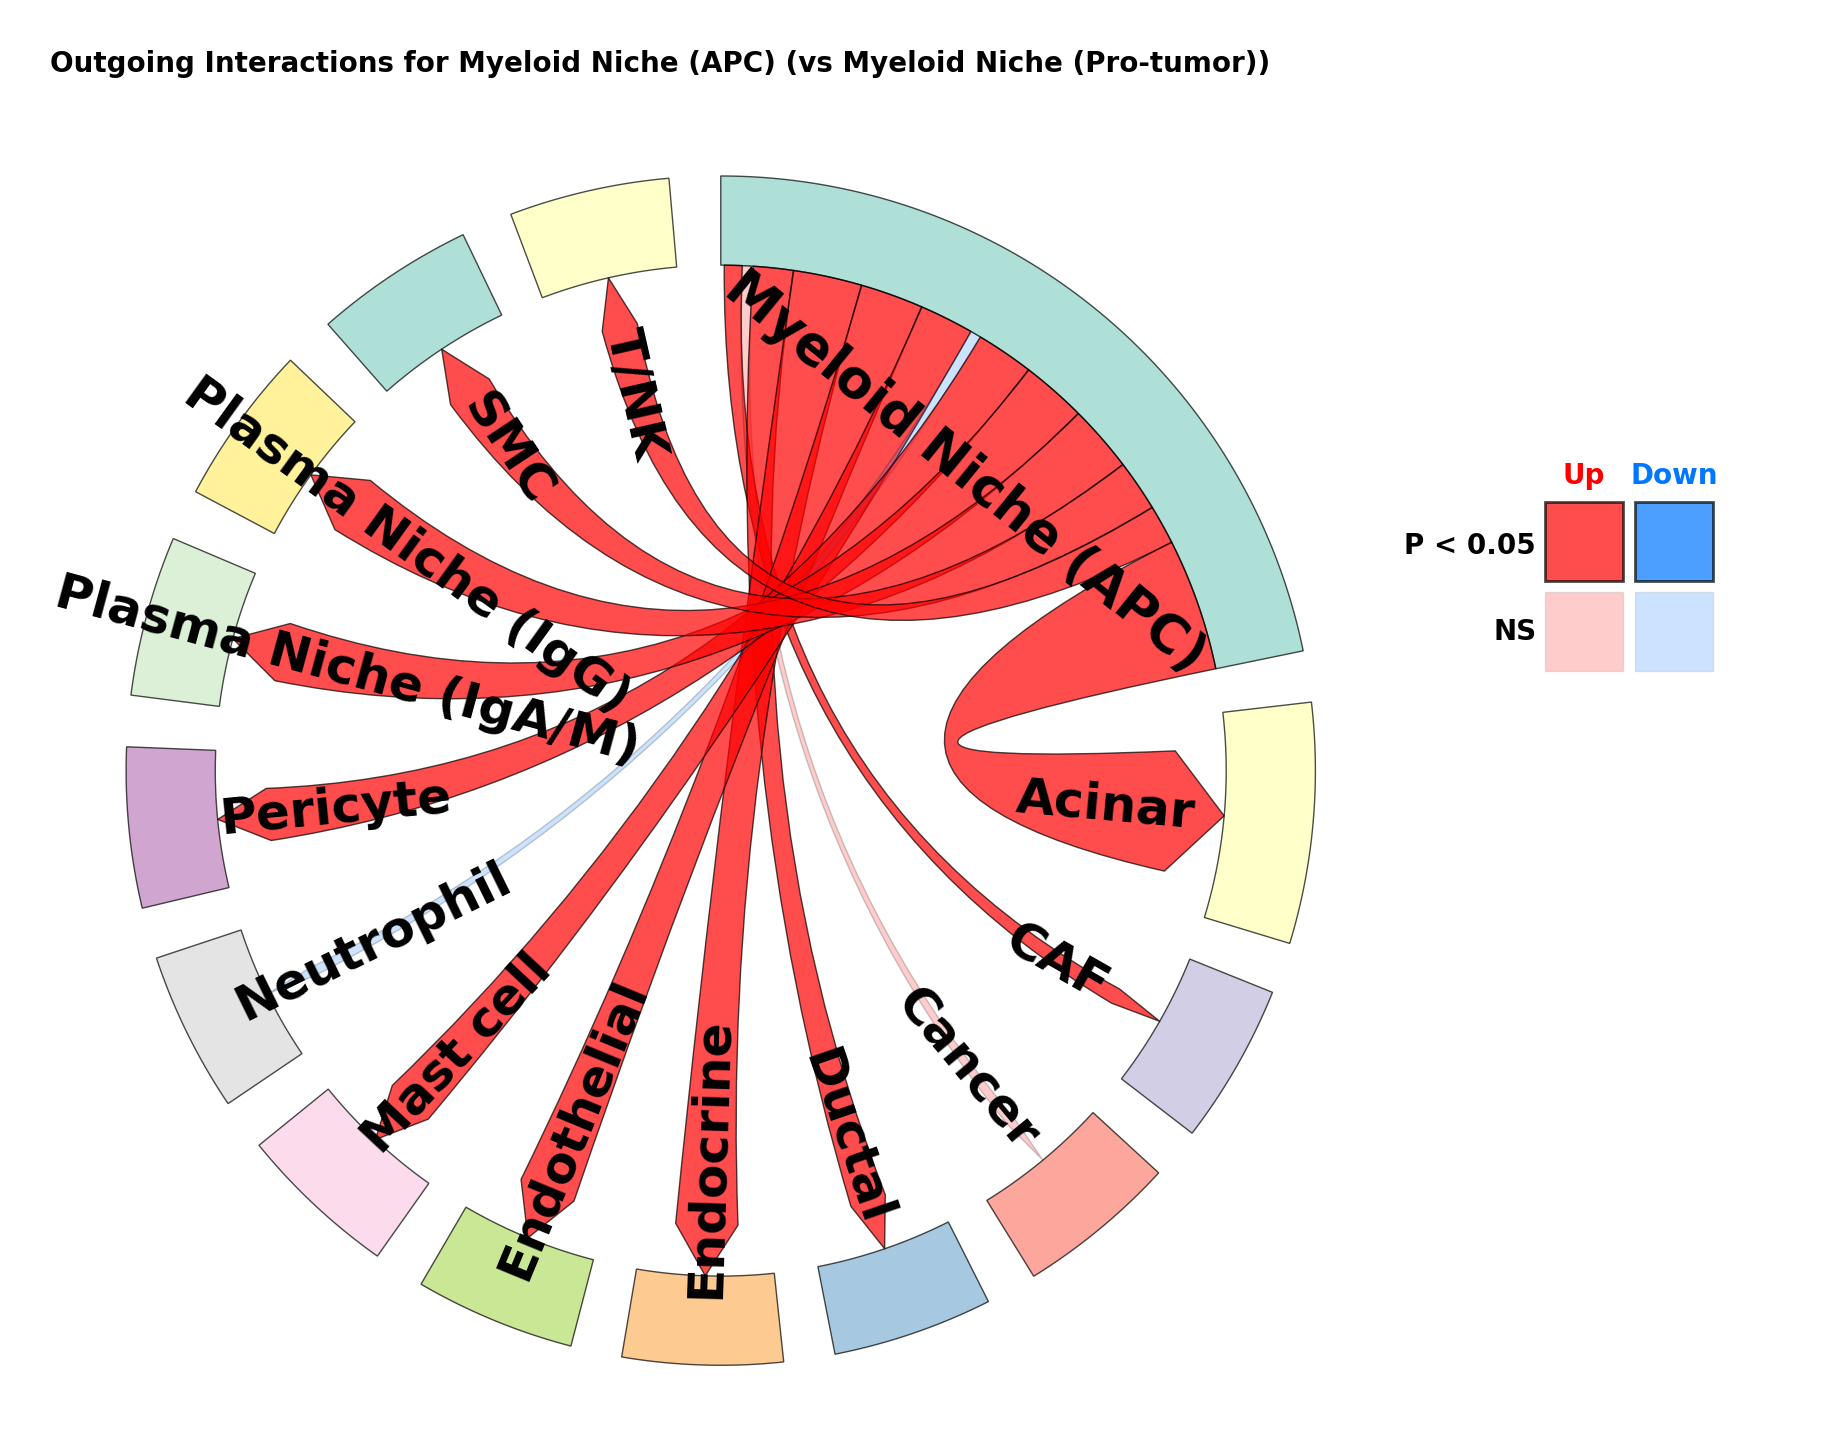

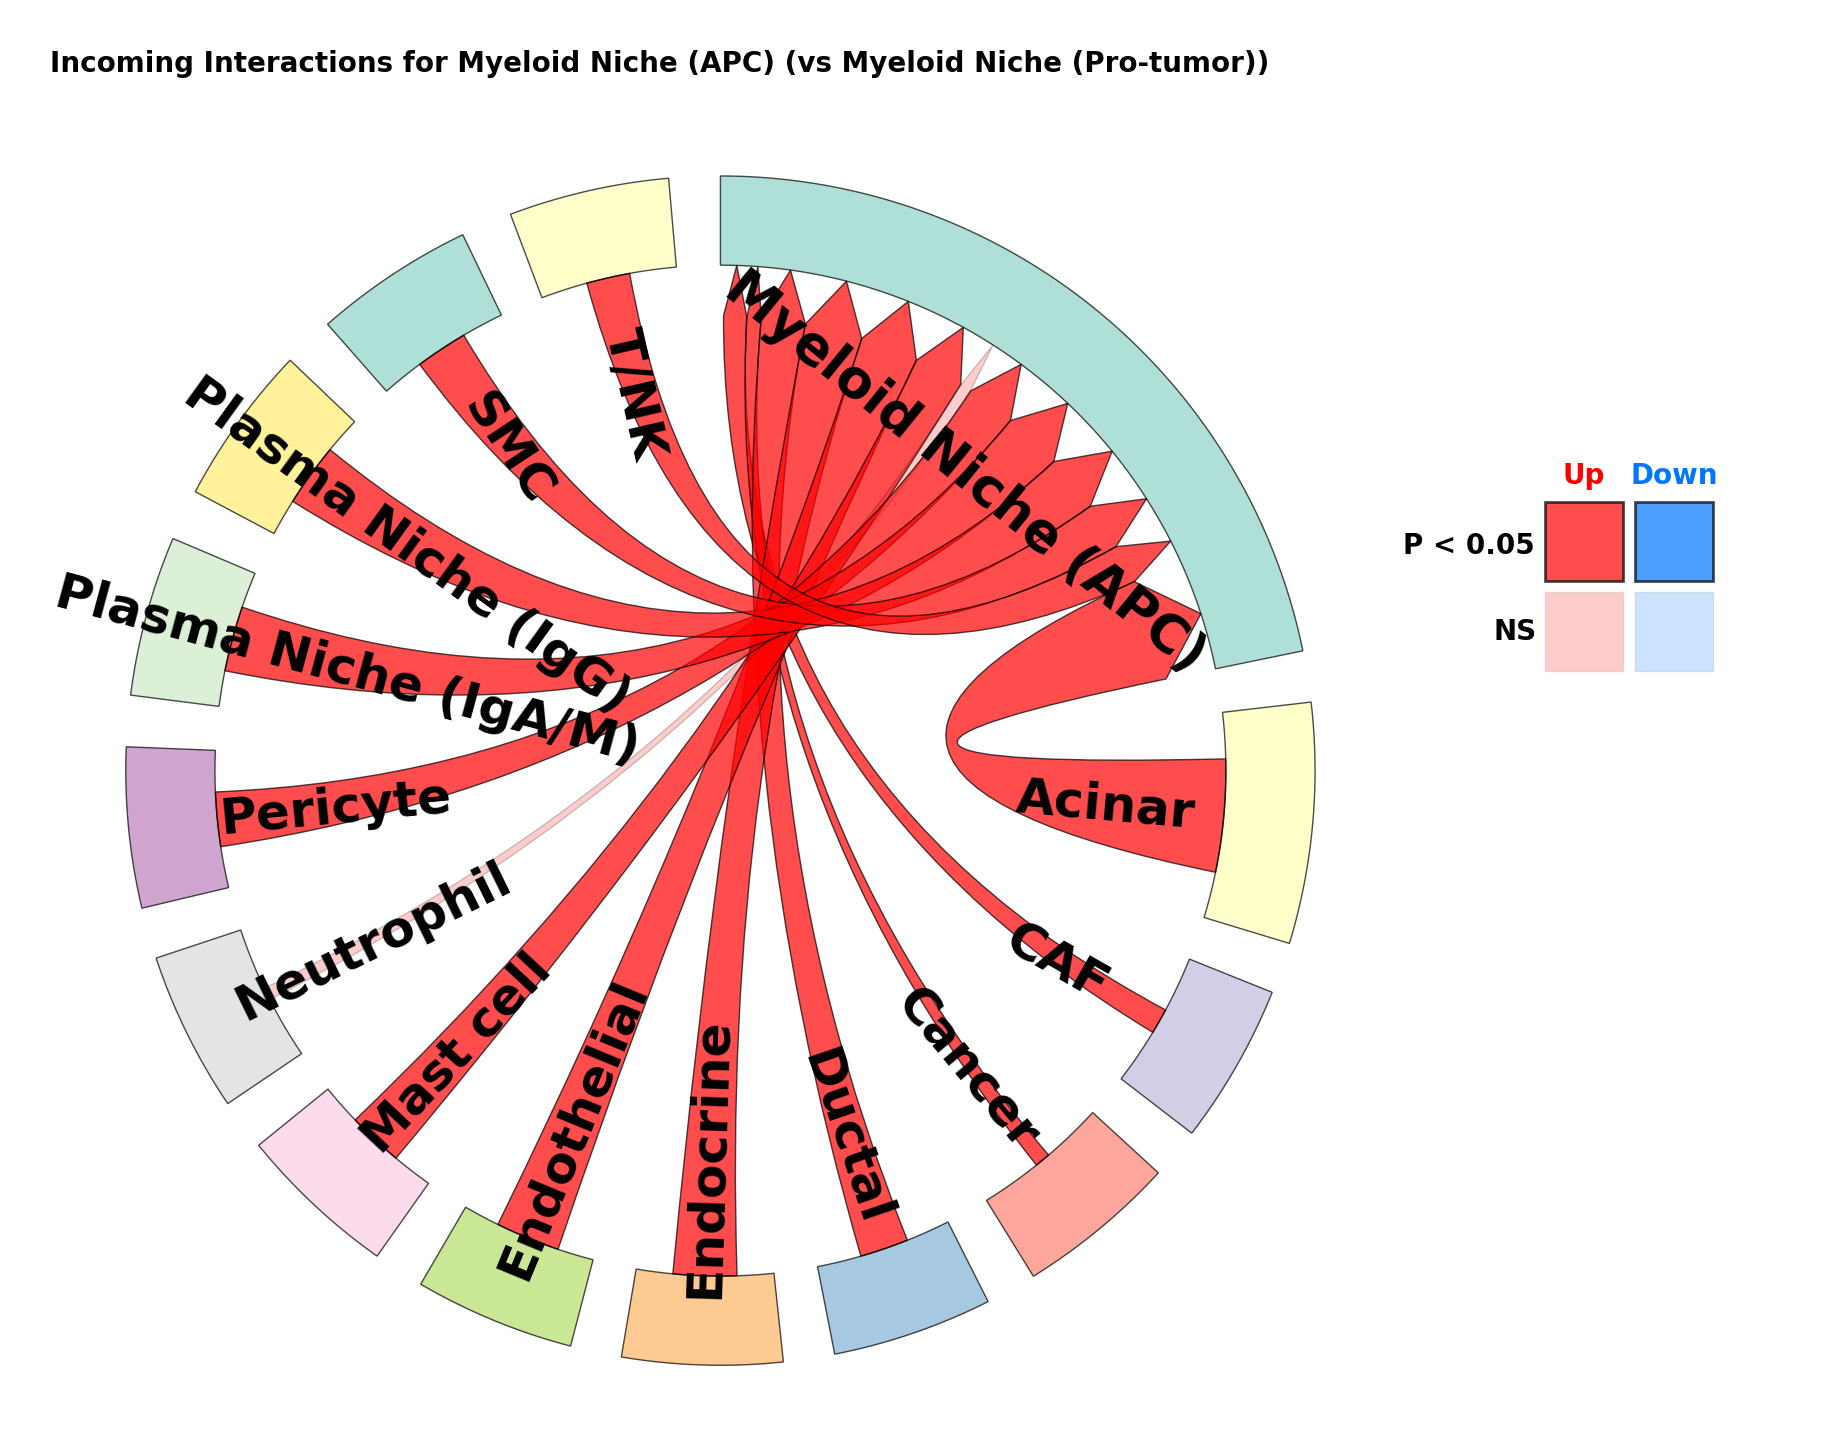

 Processing neighbor: Acinar
Significant pairs for outgoing from Myeloid Niche (Pro-tumor) to Acinar (Myeloid Niche (Pro-tumor) vs Myeloid Niche (APC)): 432
Significant pairs for incoming from Acinar to Myeloid Niche (Pro-tumor) (Myeloid Niche (Pro-tumor) vs Myeloid Niche (APC)): 246
 Processing neighbor: CAF
Significant pairs for outgoing from Myeloid Niche (Pro-tumor) to CAF (Myeloid Niche (Pro-tumor) vs Myeloid Niche (APC)): 510
Significant pairs for incoming from CAF to Myeloid Niche (Pro-tumor) (Myeloid Niche (Pro-tumor) vs Myeloid Niche (APC)): 292


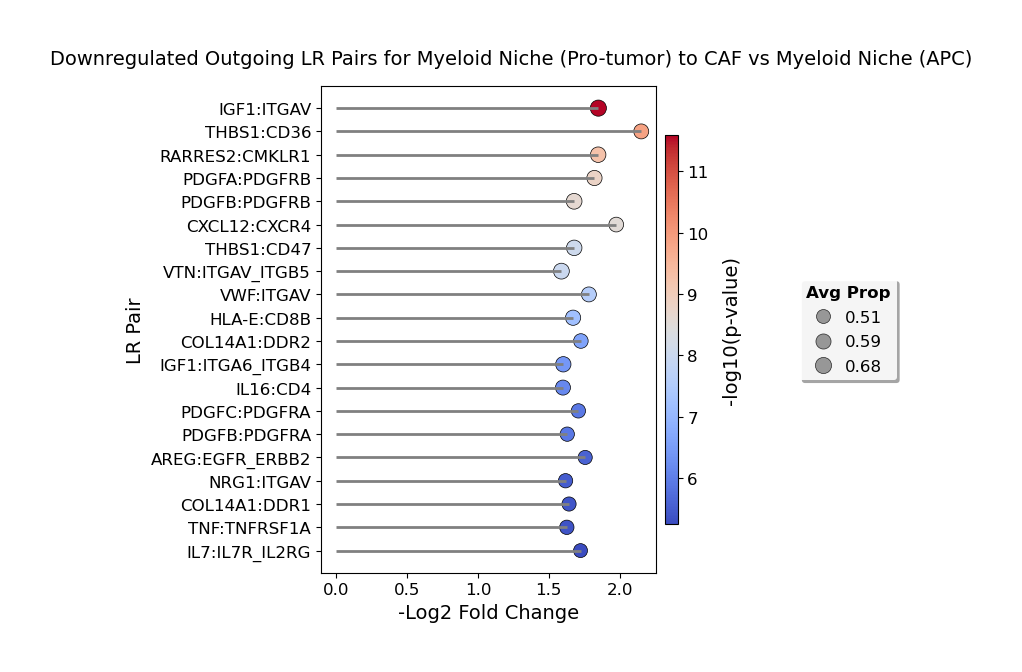

Downregulated outgoing pairs for Myeloid Niche (Pro-tumor) -> CAF: 20 interactions | FC range: 1.59-2.15 | Expr range: 0.51-0.68


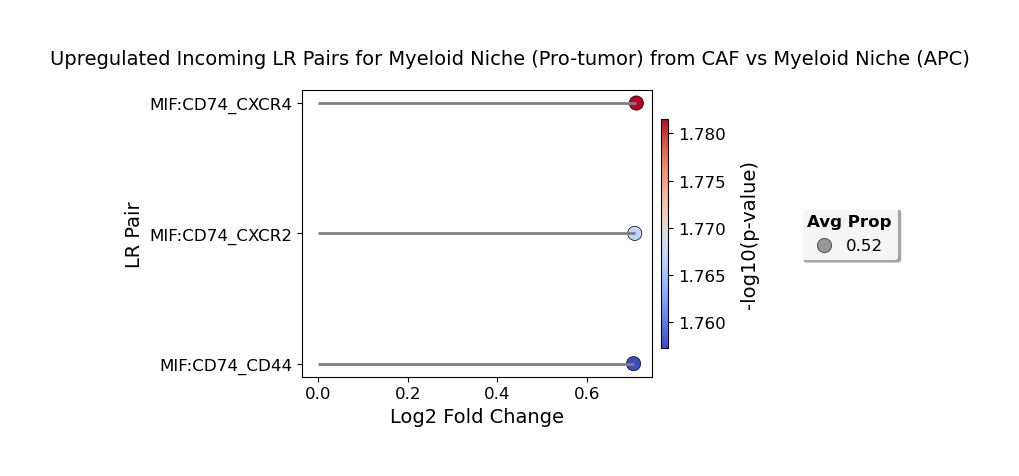

Upregulated incoming pairs for CAF -> Myeloid Niche (Pro-tumor): 3 interactions | FC range: 0.70-0.71 | Expr range: 0.52-0.52
 Processing neighbor: Cancer
Significant pairs for outgoing from Myeloid Niche (Pro-tumor) to Cancer (Myeloid Niche (Pro-tumor) vs Myeloid Niche (APC)): 22
Significant pairs for incoming from Cancer to Myeloid Niche (Pro-tumor) (Myeloid Niche (Pro-tumor) vs Myeloid Niche (APC)): 241


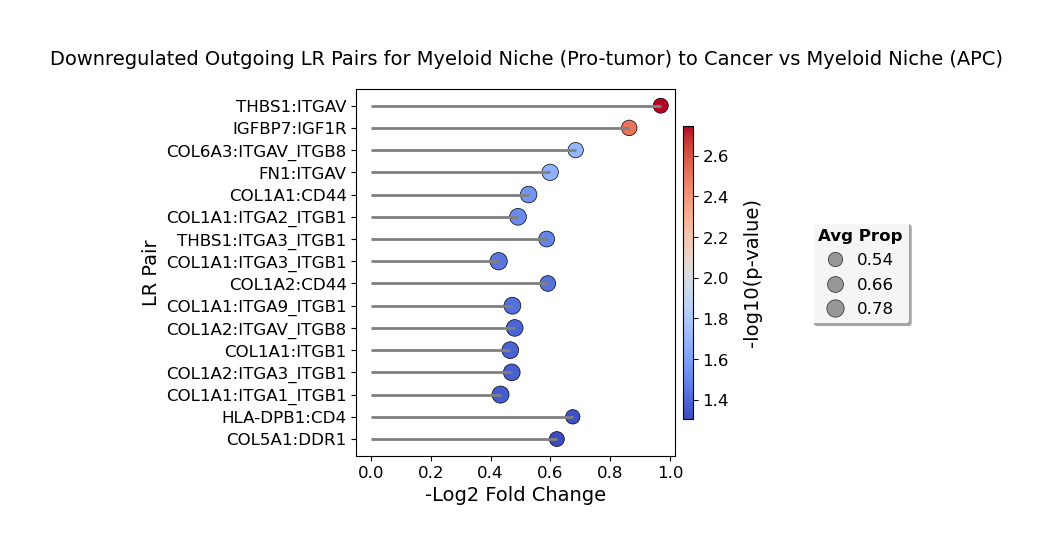

Downregulated outgoing pairs for Myeloid Niche (Pro-tumor) -> Cancer: 16 interactions | FC range: 0.43-0.97 | Expr range: 0.54-0.78
 Processing neighbor: Ductal
Significant pairs for outgoing from Myeloid Niche (Pro-tumor) to Ductal (Myeloid Niche (Pro-tumor) vs Myeloid Niche (APC)): 507
Significant pairs for incoming from Ductal to Myeloid Niche (Pro-tumor) (Myeloid Niche (Pro-tumor) vs Myeloid Niche (APC)): 131
 Processing neighbor: Endocrine
Significant pairs for outgoing from Myeloid Niche (Pro-tumor) to Endocrine (Myeloid Niche (Pro-tumor) vs Myeloid Niche (APC)): 380
Significant pairs for incoming from Endocrine to Myeloid Niche (Pro-tumor) (Myeloid Niche (Pro-tumor) vs Myeloid Niche (APC)): 194
 Processing neighbor: Endothelial
Significant pairs for outgoing from Myeloid Niche (Pro-tumor) to Endothelial (Myeloid Niche (Pro-tumor) vs Myeloid Niche (APC)): 579
Significant pairs for incoming from Endothelial to Myeloid Niche (Pro-tumor) (Myeloid Niche (Pro-tumor) vs Myeloid Niche (

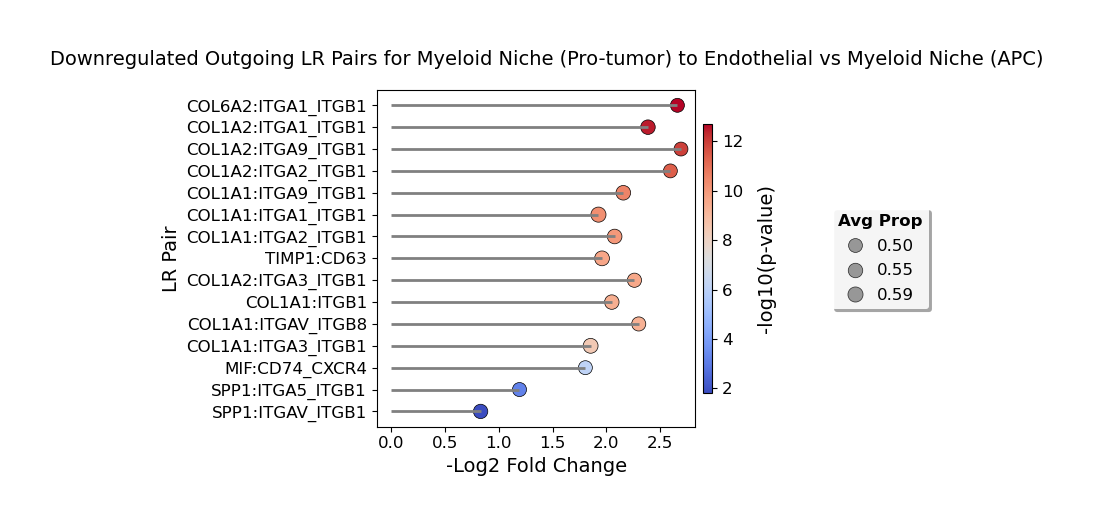

Downregulated outgoing pairs for Myeloid Niche (Pro-tumor) -> Endothelial: 15 interactions | FC range: 0.83-2.69 | Expr range: 0.50-0.59
 Processing neighbor: Mast cell
Significant pairs for outgoing from Myeloid Niche (Pro-tumor) to Mast cell (Myeloid Niche (Pro-tumor) vs Myeloid Niche (APC)): 425
Significant pairs for incoming from Mast cell to Myeloid Niche (Pro-tumor) (Myeloid Niche (Pro-tumor) vs Myeloid Niche (APC)): 136


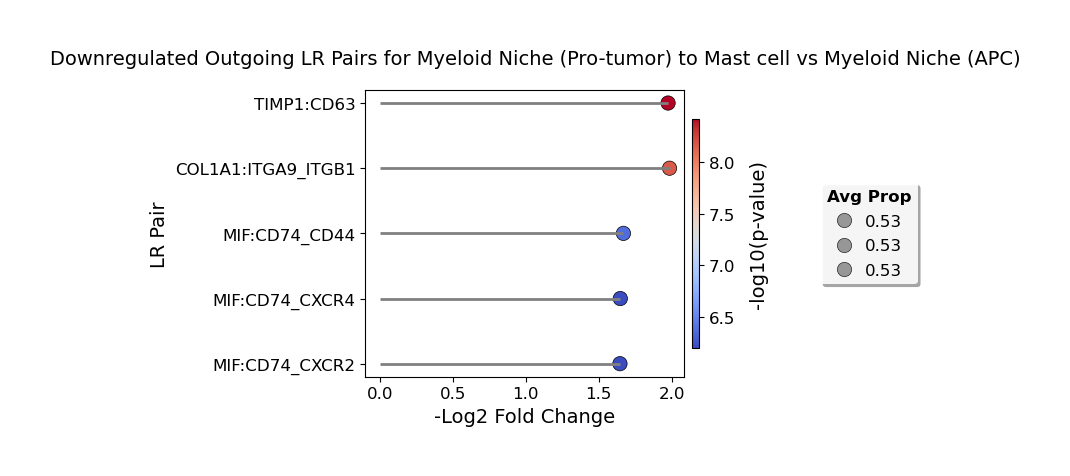

Downregulated outgoing pairs for Myeloid Niche (Pro-tumor) -> Mast cell: 5 interactions | FC range: 1.65-1.99 | Expr range: 0.53-0.53
 Processing neighbor: Myeloid Niche (APC)
Significant pairs for outgoing from Myeloid Niche (Pro-tumor) to Myeloid Niche (APC) (Myeloid Niche (Pro-tumor) vs Myeloid Niche (APC)): 624
Significant pairs for incoming from Myeloid Niche (APC) to Myeloid Niche (Pro-tumor) (Myeloid Niche (Pro-tumor) vs Myeloid Niche (APC)): 0


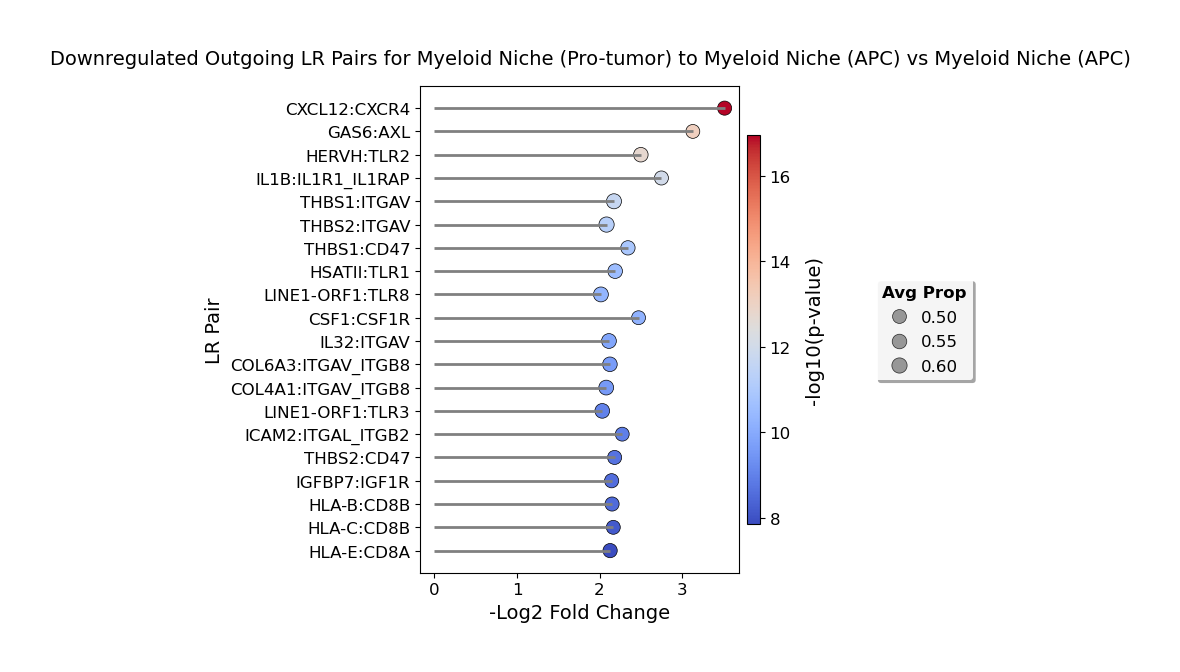

Downregulated outgoing pairs for Myeloid Niche (Pro-tumor) -> Myeloid Niche (APC): 20 interactions | FC range: 2.02-3.52 | Expr range: 0.50-0.60
 Processing neighbor: Myeloid Niche (Pro-tumor)
Significant pairs for outgoing from Myeloid Niche (Pro-tumor) to Myeloid Niche (Pro-tumor) (Myeloid Niche (Pro-tumor) vs Myeloid Niche (APC)): 507
Significant pairs for incoming from Myeloid Niche (Pro-tumor) to Myeloid Niche (Pro-tumor) (Myeloid Niche (Pro-tumor) vs Myeloid Niche (APC)): 507


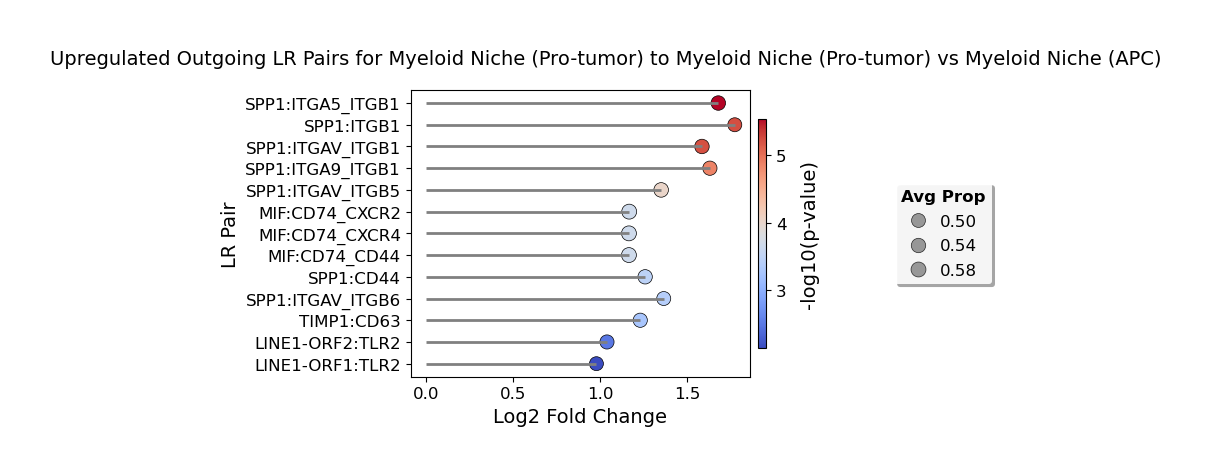

Upregulated outgoing pairs for Myeloid Niche (Pro-tumor) -> Myeloid Niche (Pro-tumor): 13 interactions | FC range: 0.98-1.77 | Expr range: 0.50-0.58


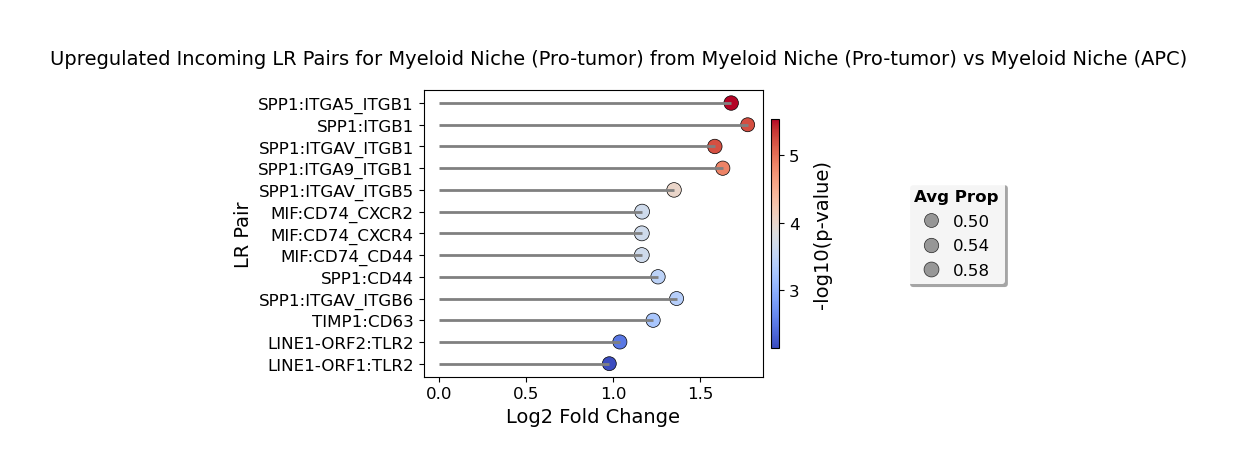

Upregulated incoming pairs for Myeloid Niche (Pro-tumor) -> Myeloid Niche (Pro-tumor): 13 interactions | FC range: 0.98-1.77 | Expr range: 0.50-0.58
 Processing neighbor: Neutrophil
Significant pairs for outgoing from Myeloid Niche (Pro-tumor) to Neutrophil (Myeloid Niche (Pro-tumor) vs Myeloid Niche (APC)): 10
Significant pairs for incoming from Neutrophil to Myeloid Niche (Pro-tumor) (Myeloid Niche (Pro-tumor) vs Myeloid Niche (APC)): 36
 Processing neighbor: Pericyte
Significant pairs for outgoing from Myeloid Niche (Pro-tumor) to Pericyte (Myeloid Niche (Pro-tumor) vs Myeloid Niche (APC)): 540
Significant pairs for incoming from Pericyte to Myeloid Niche (Pro-tumor) (Myeloid Niche (Pro-tumor) vs Myeloid Niche (APC)): 113


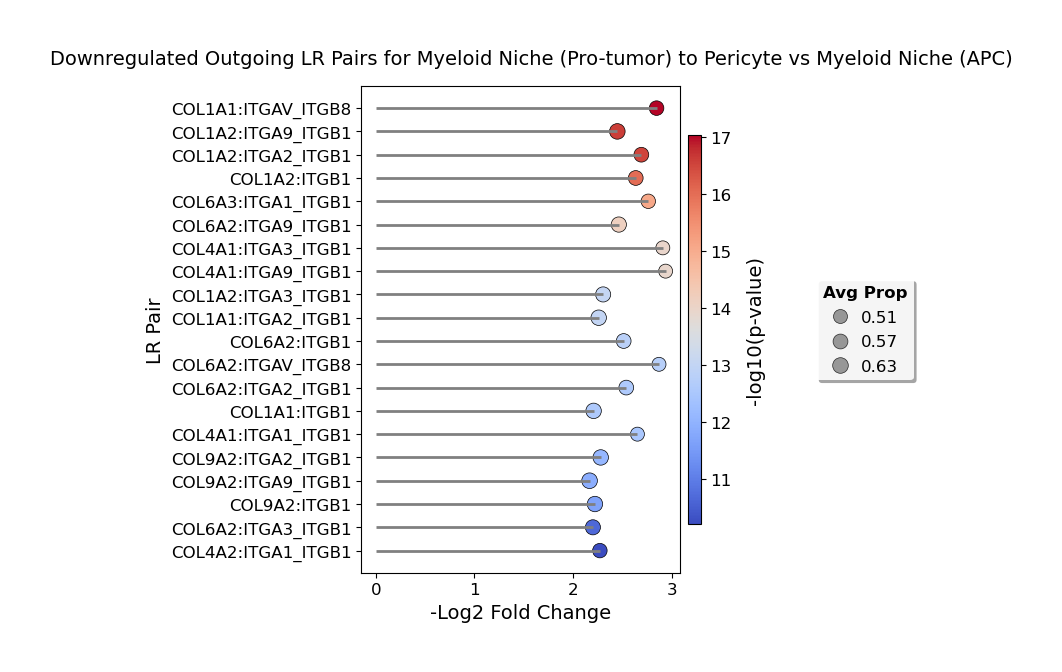

Downregulated outgoing pairs for Myeloid Niche (Pro-tumor) -> Pericyte: 20 interactions | FC range: 2.17-2.94 | Expr range: 0.51-0.63
 Processing neighbor: Plasma Niche (IgA/M)
Significant pairs for outgoing from Myeloid Niche (Pro-tumor) to Plasma Niche (IgA/M) (Myeloid Niche (Pro-tumor) vs Myeloid Niche (APC)): 543
Significant pairs for incoming from Plasma Niche (IgA/M) to Myeloid Niche (Pro-tumor) (Myeloid Niche (Pro-tumor) vs Myeloid Niche (APC)): 143
 Processing neighbor: Plasma Niche (IgG)
Significant pairs for outgoing from Myeloid Niche (Pro-tumor) to Plasma Niche (IgG) (Myeloid Niche (Pro-tumor) vs Myeloid Niche (APC)): 269
Significant pairs for incoming from Plasma Niche (IgG) to Myeloid Niche (Pro-tumor) (Myeloid Niche (Pro-tumor) vs Myeloid Niche (APC)): 194
 Processing neighbor: SMC
Significant pairs for outgoing from Myeloid Niche (Pro-tumor) to SMC (Myeloid Niche (Pro-tumor) vs Myeloid Niche (APC)): 147
Significant pairs for incoming from SMC to Myeloid Niche (Pro-tumor

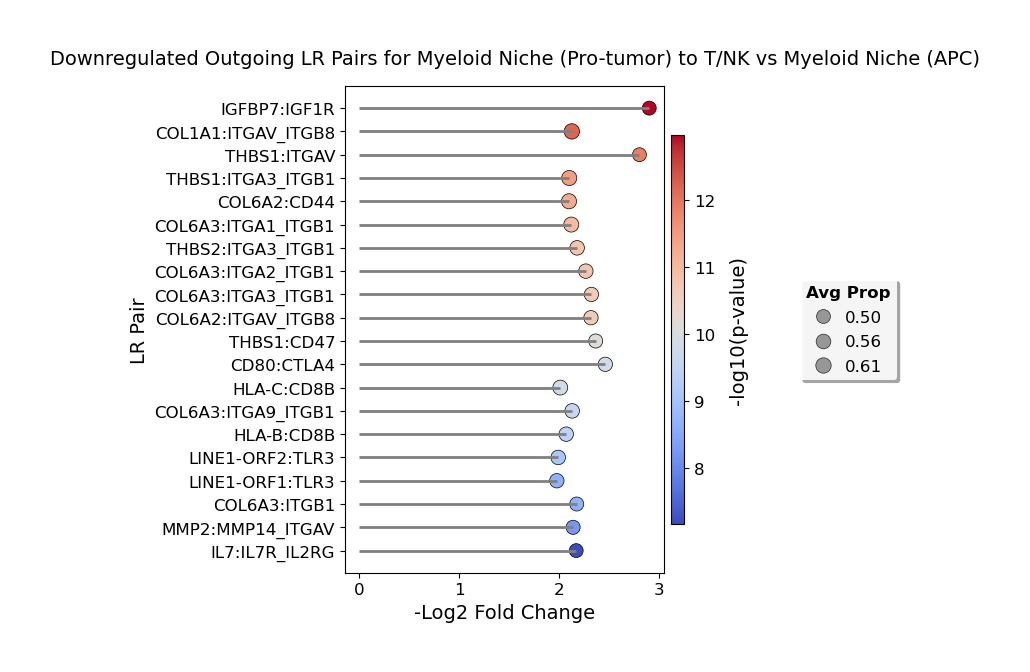

Downregulated outgoing pairs for Myeloid Niche (Pro-tumor) -> T/NK: 20 interactions | FC range: 1.98-2.91 | Expr range: 0.50-0.61


In [26]:
# SCENARIO 1: Cell type comparison
plot_configs = [("Myeloid Niche (Pro-tumor)", "Myeloid Niche (APC)")]
neighbor_types = analyze_cell_type_pairs(
    adata_CCC, plot_configs, cell_type_col='niche4', 
    group_key='patient', exclude_niches=['Plasma cell', 'Myeloid',]
)

# L-R pair analysis for cell type comparison
perform_lr_plotting_cell_types(
    adata_CCC, plot_configs, cell_type_col='niche4', exclude_niches=[],
    neighbor_types=neighbor_types, 
    #selected_neighbors=['CAF', 'Pericyte'], 
    min_neg_log_p=1.3, min_avg_prop=0.5, top_n=20, sort_by='abs_log2_fc'
)

=== SCENARIO 1: CELL TYPE COMPARISON ===

--- Plasma Niche (IgA/M) vs Plasma Niche (IgG) ---
Creating plot centered on Plasma Niche (IgA/M)
Cell type comparison: Plasma Niche (IgA/M) vs Plasma Niche (IgG) (outgoing):
  Plasma Niche (IgA/M): 39 samples
  Plasma Niche (IgG): 37 samples
  Results: 13 upregulated, 0 downregulated (10 significant)
Cell type comparison: Plasma Niche (IgA/M) vs Plasma Niche (IgG) (incoming):
  Plasma Niche (IgA/M): 39 samples
  Plasma Niche (IgG): 37 samples
  Results: 13 upregulated, 0 downregulated (10 significant)


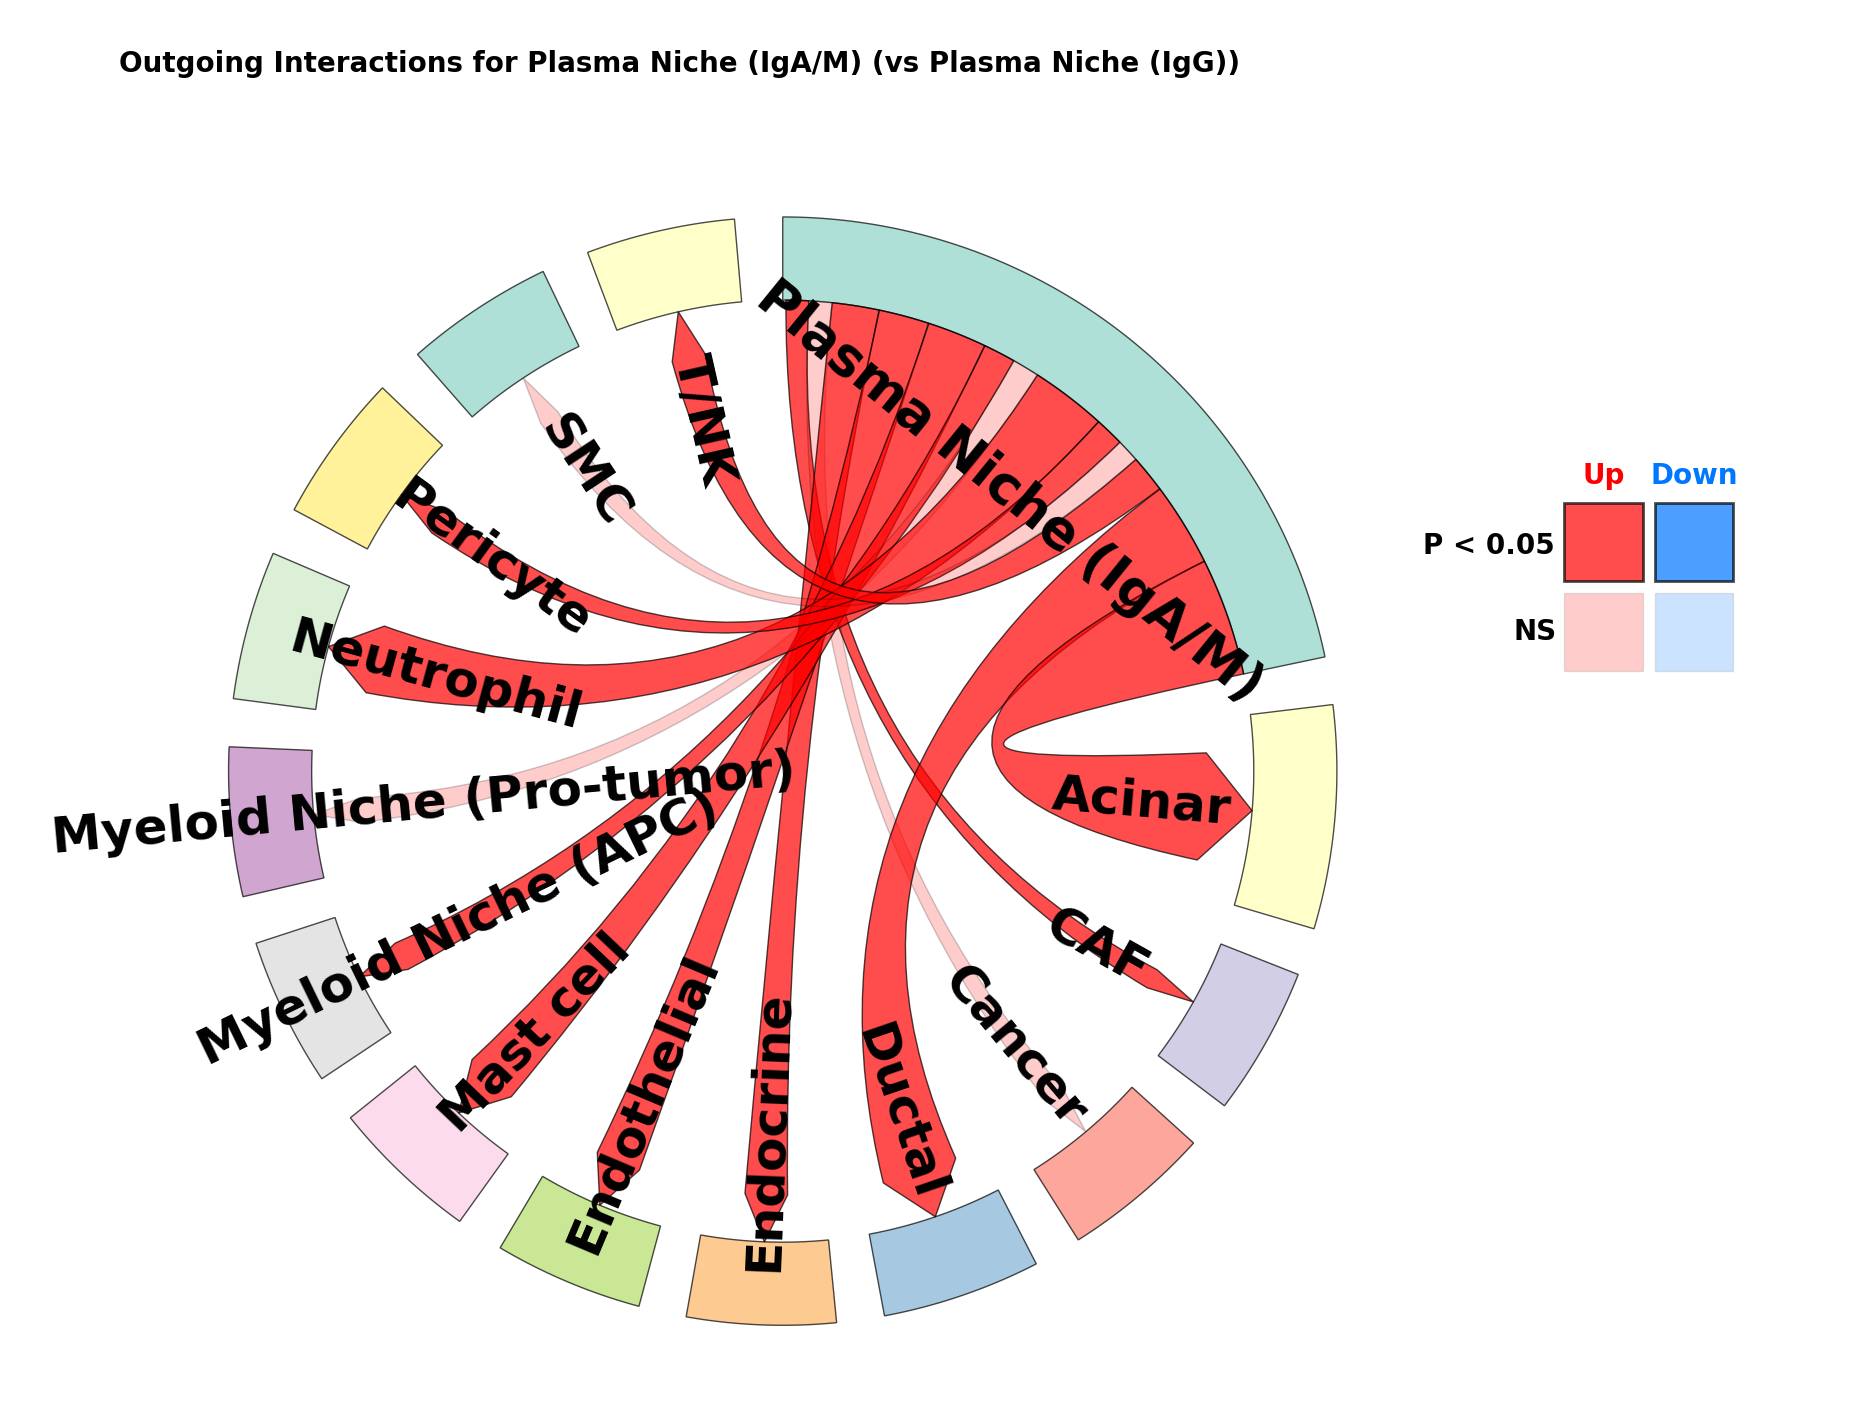

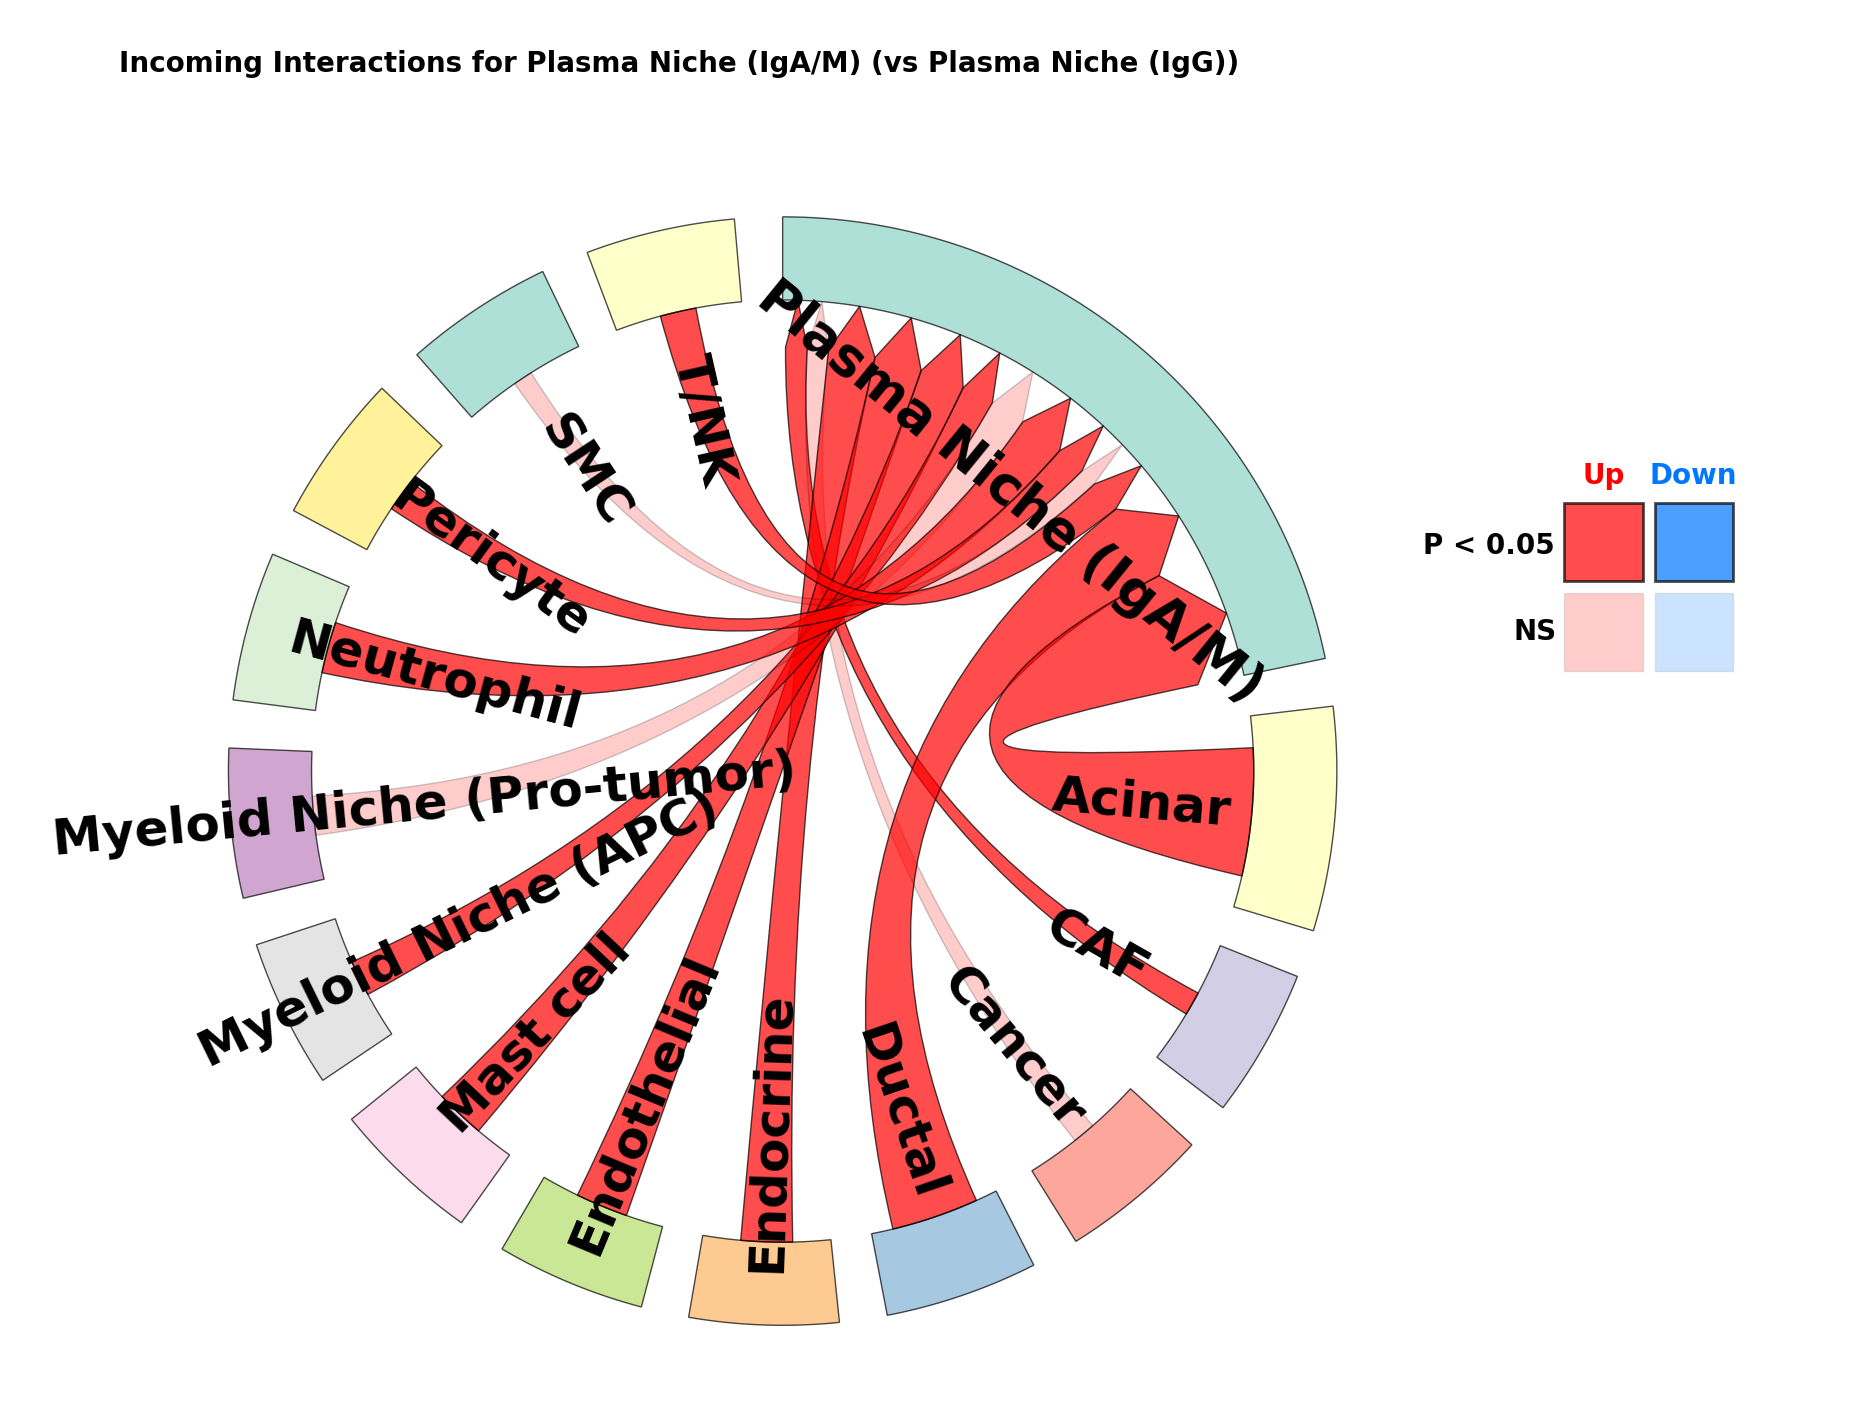

Creating plot centered on Plasma Niche (IgG)
Cell type comparison: Plasma Niche (IgG) vs Plasma Niche (IgA/M) (outgoing):
  Plasma Niche (IgG): 37 samples
  Plasma Niche (IgA/M): 39 samples
  Results: 0 upregulated, 13 downregulated (10 significant)
Cell type comparison: Plasma Niche (IgG) vs Plasma Niche (IgA/M) (incoming):
  Plasma Niche (IgG): 37 samples
  Plasma Niche (IgA/M): 39 samples
  Results: 0 upregulated, 13 downregulated (10 significant)


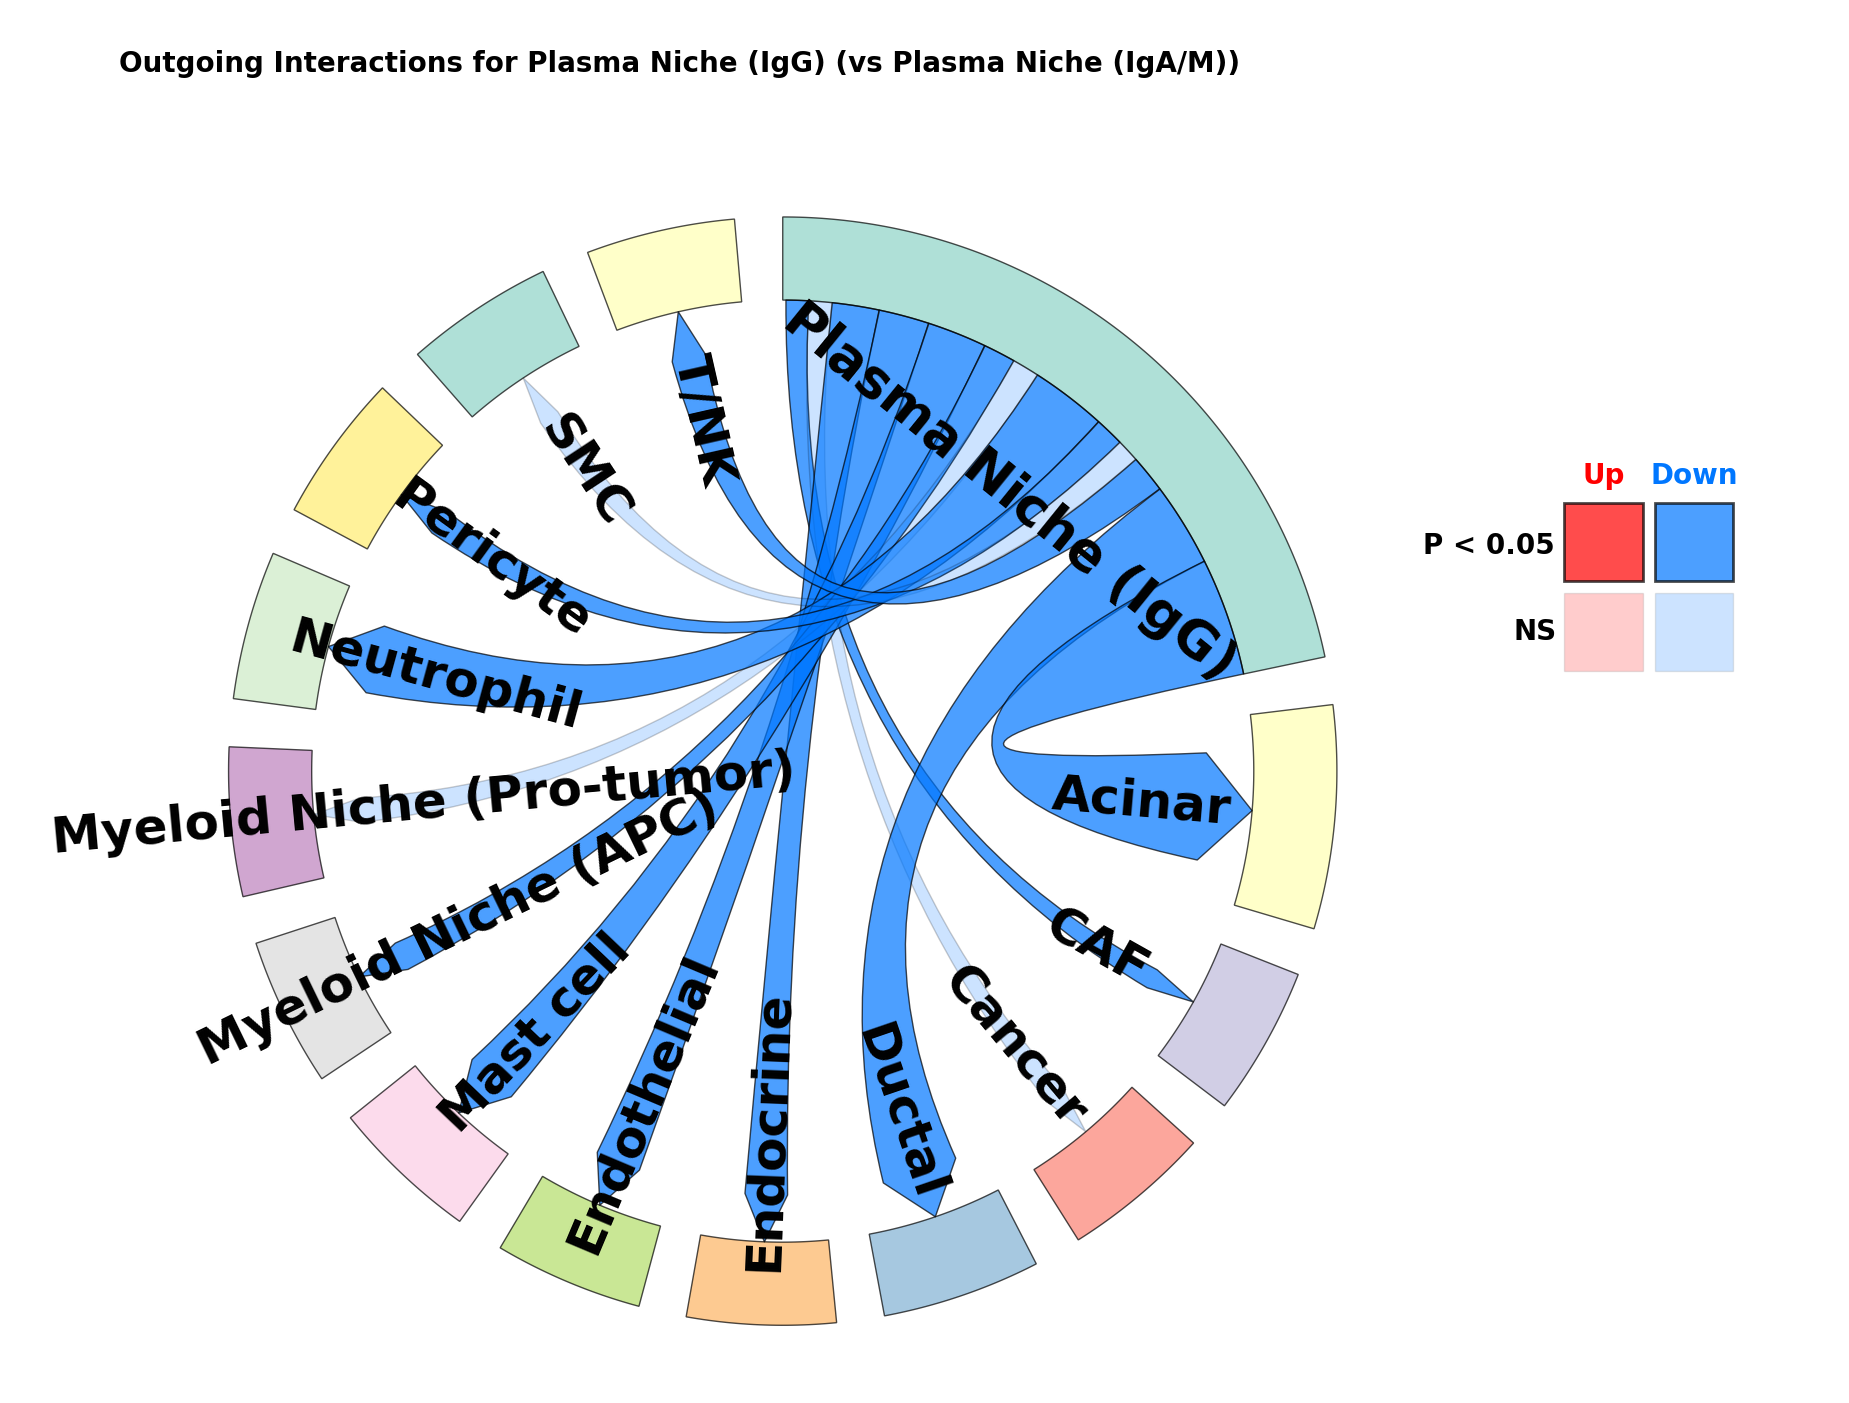

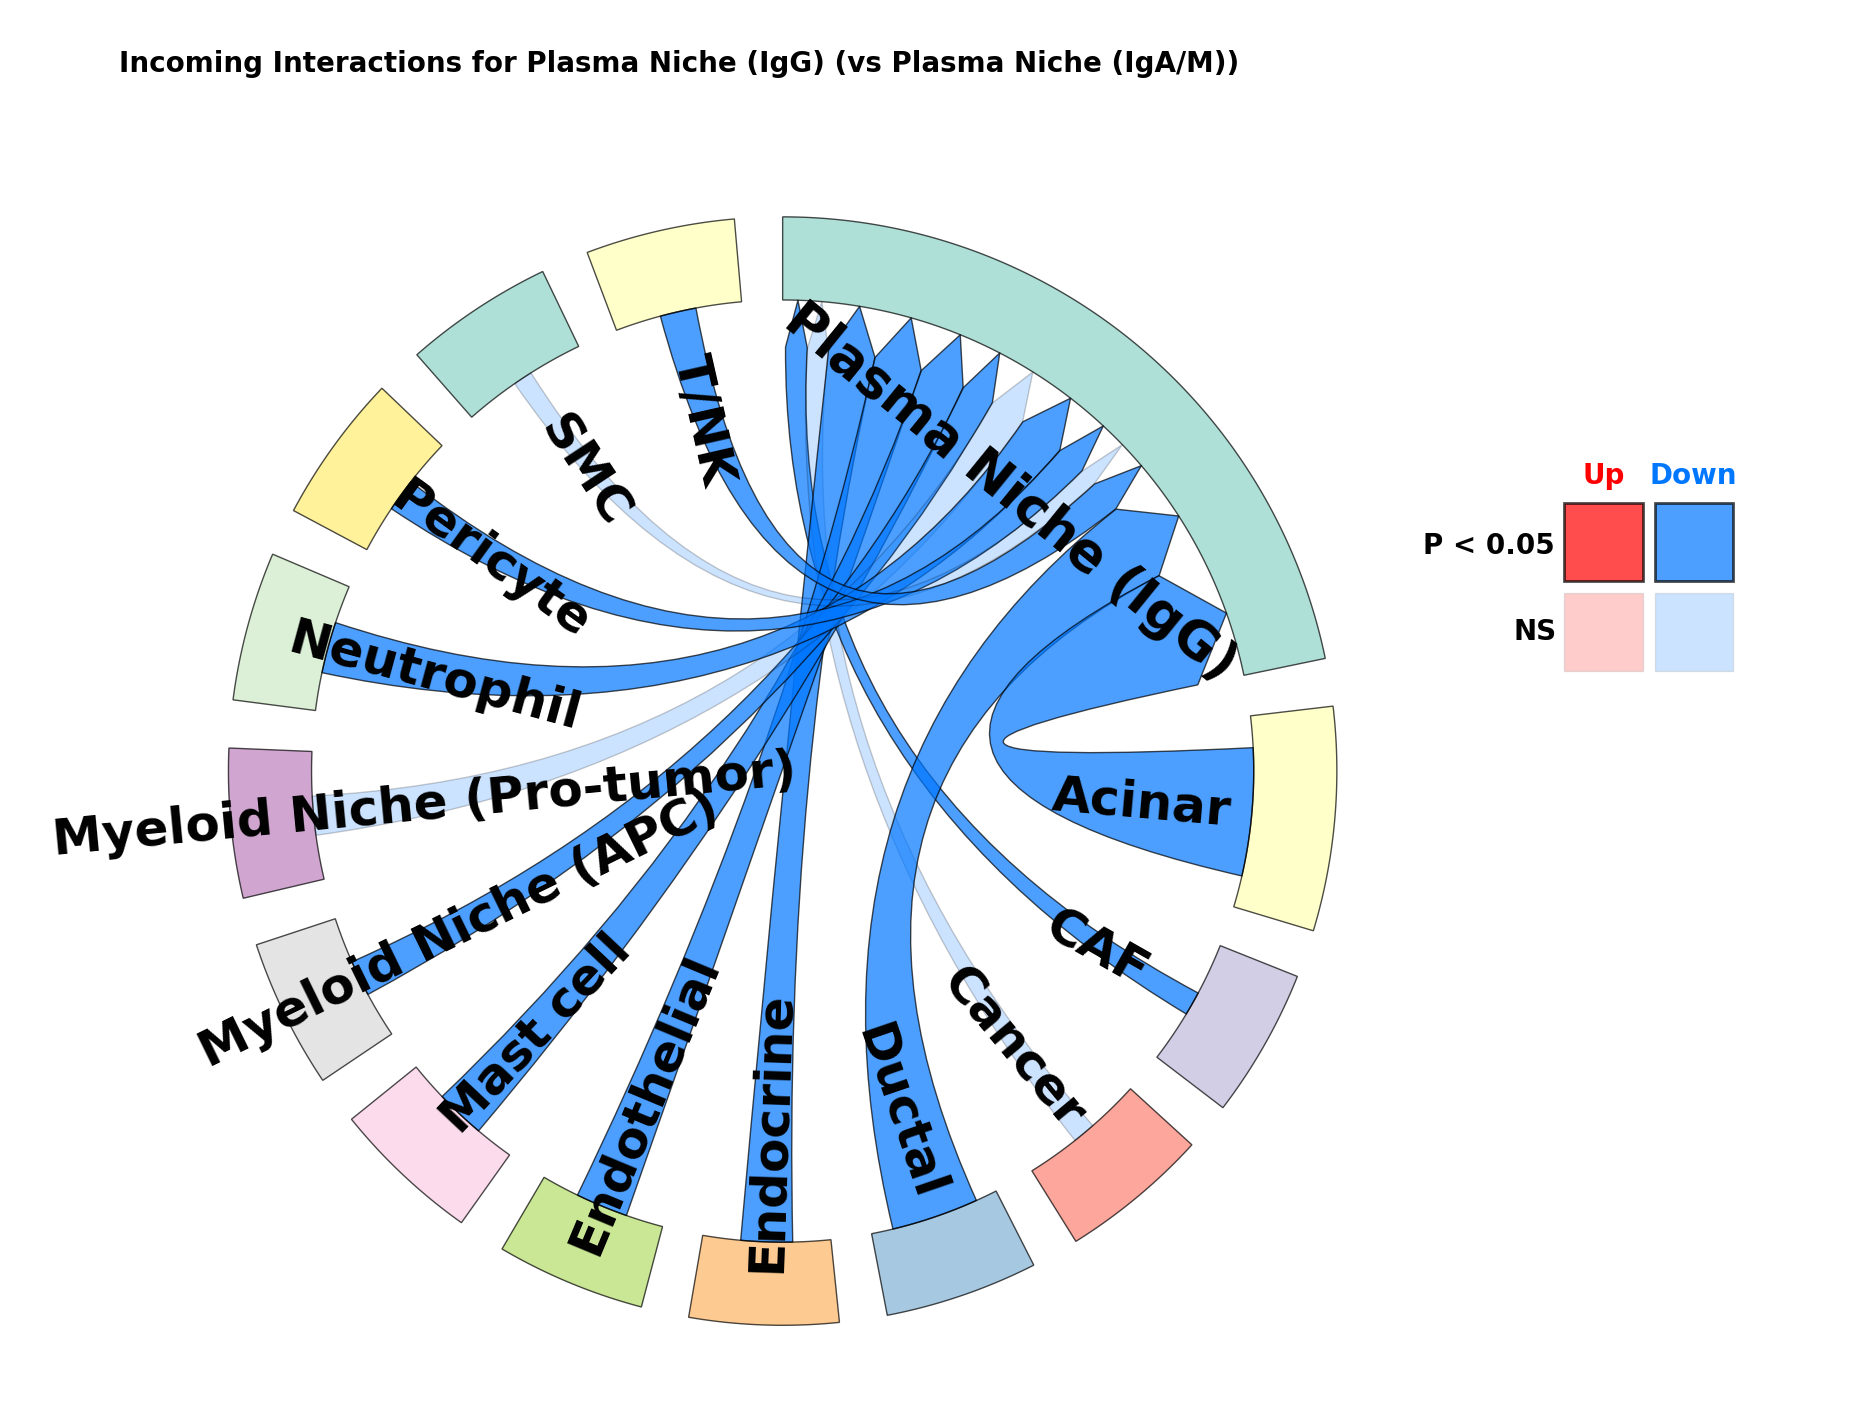

 Processing neighbor: Acinar
Significant pairs for outgoing from Plasma Niche (IgA/M) to Acinar (Plasma Niche (IgA/M) vs Plasma Niche (IgG)): 104
Significant pairs for incoming from Acinar to Plasma Niche (IgA/M) (Plasma Niche (IgA/M) vs Plasma Niche (IgG)): 102
 Processing neighbor: CAF
Significant pairs for outgoing from Plasma Niche (IgA/M) to CAF (Plasma Niche (IgA/M) vs Plasma Niche (IgG)): 186
Significant pairs for incoming from CAF to Plasma Niche (IgA/M) (Plasma Niche (IgA/M) vs Plasma Niche (IgG)): 263


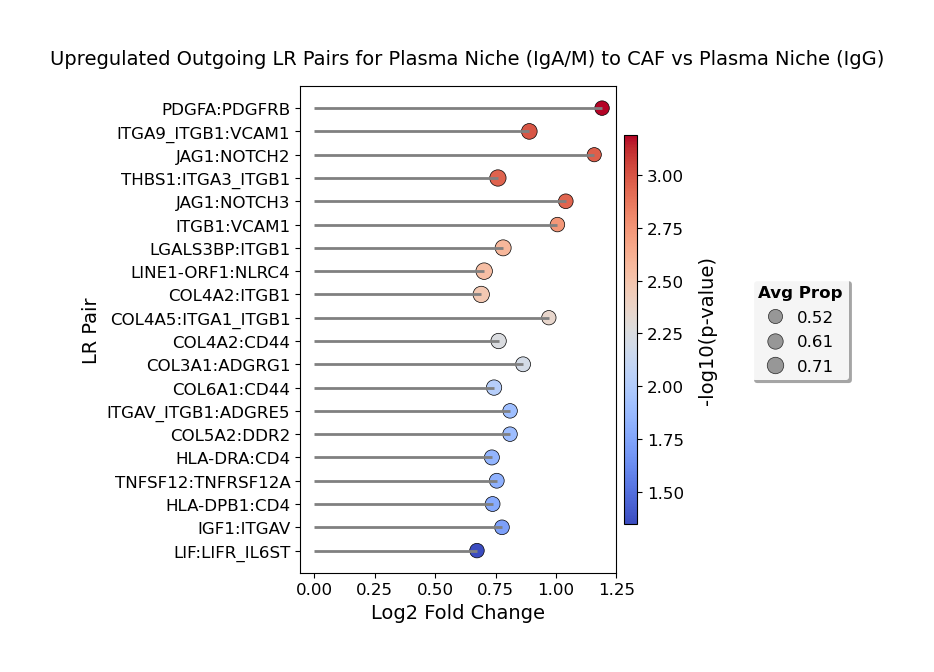

Upregulated outgoing pairs for Plasma Niche (IgA/M) -> CAF: 20 interactions | FC range: 0.67-1.19 | Expr range: 0.52-0.71


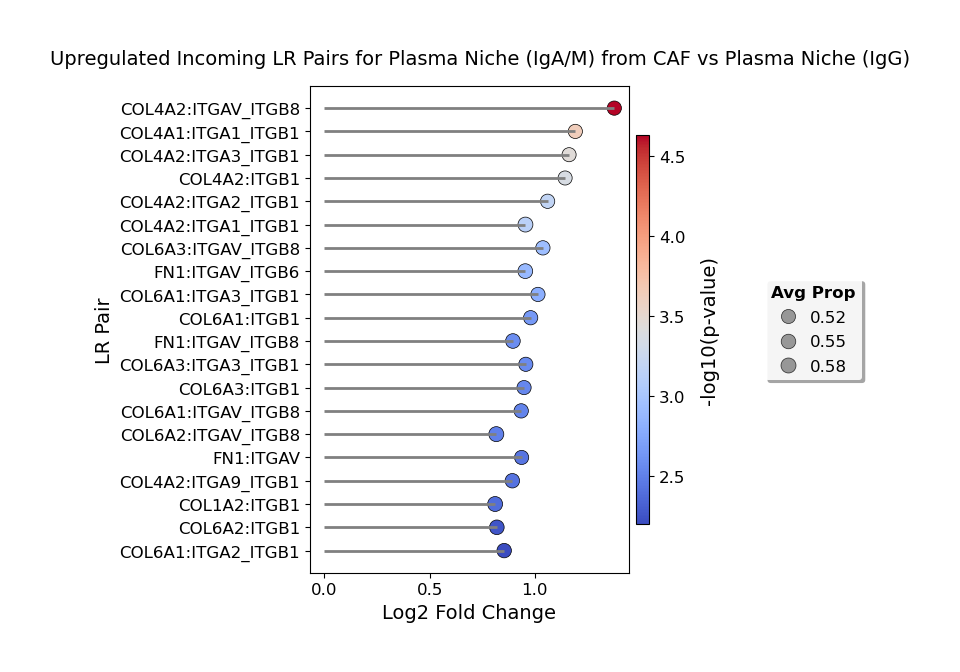

Upregulated incoming pairs for CAF -> Plasma Niche (IgA/M): 20 interactions | FC range: 0.81-1.38 | Expr range: 0.52-0.58
 Processing neighbor: Cancer
Significant pairs for outgoing from Plasma Niche (IgA/M) to Cancer (Plasma Niche (IgA/M) vs Plasma Niche (IgG)): 27
Significant pairs for incoming from Cancer to Plasma Niche (IgA/M) (Plasma Niche (IgA/M) vs Plasma Niche (IgG)): 142


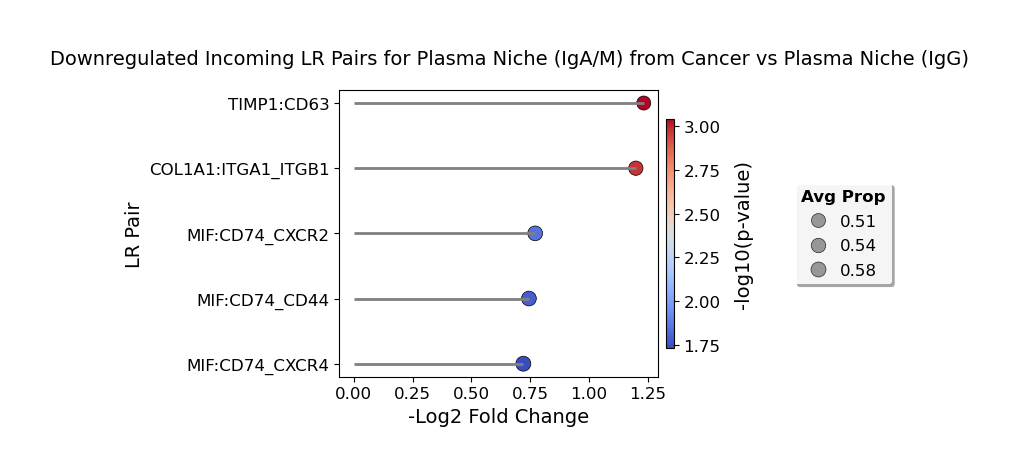

Downregulated incoming pairs for Cancer -> Plasma Niche (IgA/M): 5 interactions | FC range: 0.72-1.23 | Expr range: 0.51-0.58
 Processing neighbor: Ductal
Significant pairs for outgoing from Plasma Niche (IgA/M) to Ductal (Plasma Niche (IgA/M) vs Plasma Niche (IgG)): 229
Significant pairs for incoming from Ductal to Plasma Niche (IgA/M) (Plasma Niche (IgA/M) vs Plasma Niche (IgG)): 125


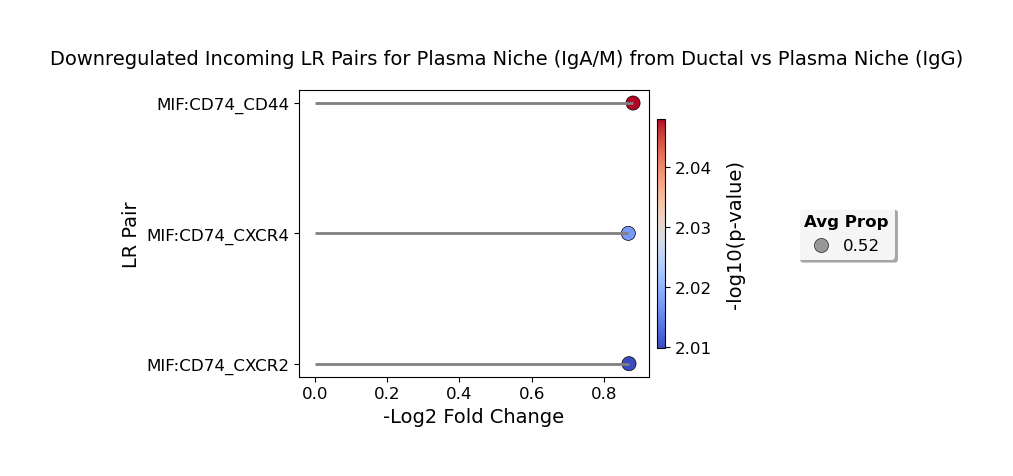

Downregulated incoming pairs for Ductal -> Plasma Niche (IgA/M): 3 interactions | FC range: 0.87-0.88 | Expr range: 0.52-0.52
 Processing neighbor: Endocrine
Significant pairs for outgoing from Plasma Niche (IgA/M) to Endocrine (Plasma Niche (IgA/M) vs Plasma Niche (IgG)): 41
Significant pairs for incoming from Endocrine to Plasma Niche (IgA/M) (Plasma Niche (IgA/M) vs Plasma Niche (IgG)): 125


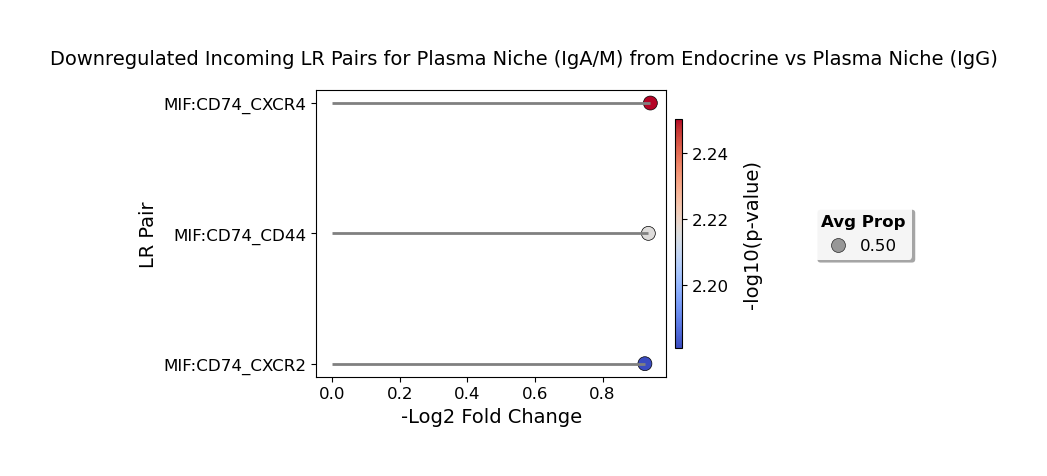

Downregulated incoming pairs for Endocrine -> Plasma Niche (IgA/M): 3 interactions | FC range: 0.93-0.94 | Expr range: 0.50-0.50
 Processing neighbor: Endothelial
Significant pairs for outgoing from Plasma Niche (IgA/M) to Endothelial (Plasma Niche (IgA/M) vs Plasma Niche (IgG)): 185
Significant pairs for incoming from Endothelial to Plasma Niche (IgA/M) (Plasma Niche (IgA/M) vs Plasma Niche (IgG)): 39


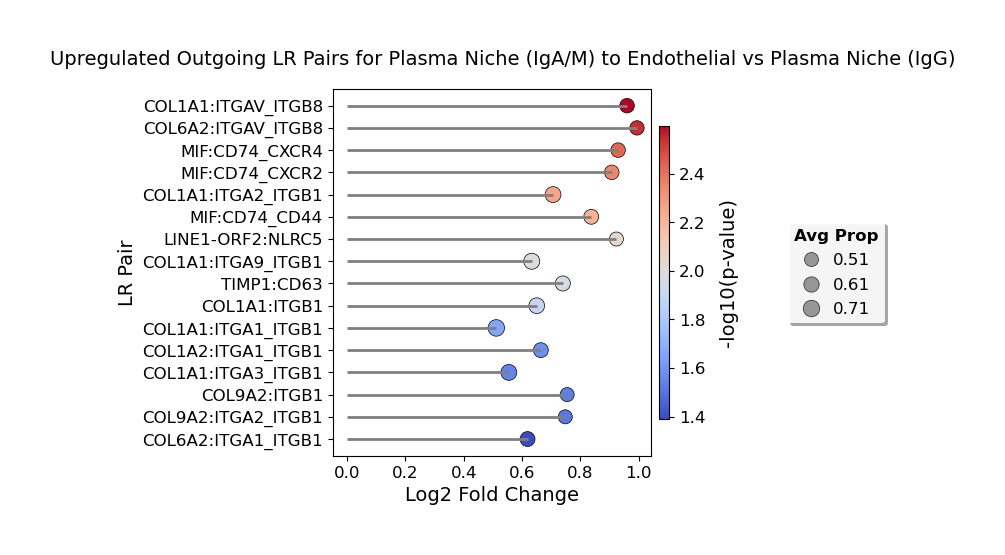

Upregulated outgoing pairs for Plasma Niche (IgA/M) -> Endothelial: 16 interactions | FC range: 0.51-0.99 | Expr range: 0.51-0.71


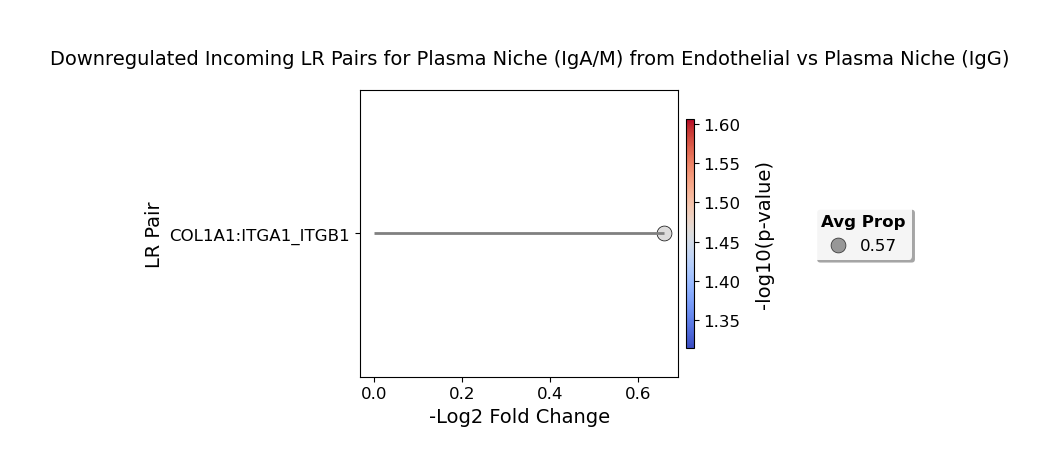

Downregulated incoming pairs for Endothelial -> Plasma Niche (IgA/M): 1 interactions | FC range: 0.66-0.66 | Expr range: 0.57-0.57
 Processing neighbor: Mast cell
Significant pairs for outgoing from Plasma Niche (IgA/M) to Mast cell (Plasma Niche (IgA/M) vs Plasma Niche (IgG)): 137
Significant pairs for incoming from Mast cell to Plasma Niche (IgA/M) (Plasma Niche (IgA/M) vs Plasma Niche (IgG)): 21


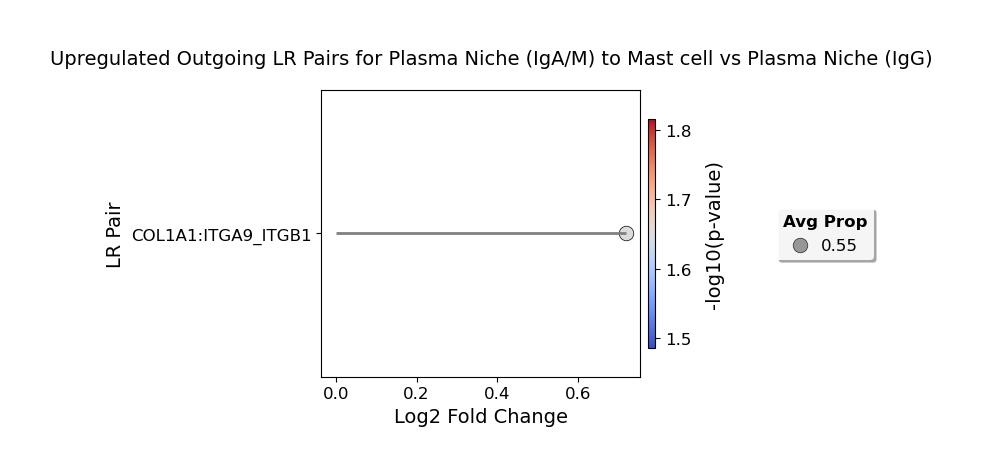

Upregulated outgoing pairs for Plasma Niche (IgA/M) -> Mast cell: 1 interactions | FC range: 0.72-0.72 | Expr range: 0.55-0.55
 Processing neighbor: Myeloid Niche (APC)
Significant pairs for outgoing from Plasma Niche (IgA/M) to Myeloid Niche (APC) (Plasma Niche (IgA/M) vs Plasma Niche (IgG)): 217
Significant pairs for incoming from Myeloid Niche (APC) to Plasma Niche (IgA/M) (Plasma Niche (IgA/M) vs Plasma Niche (IgG)): 116


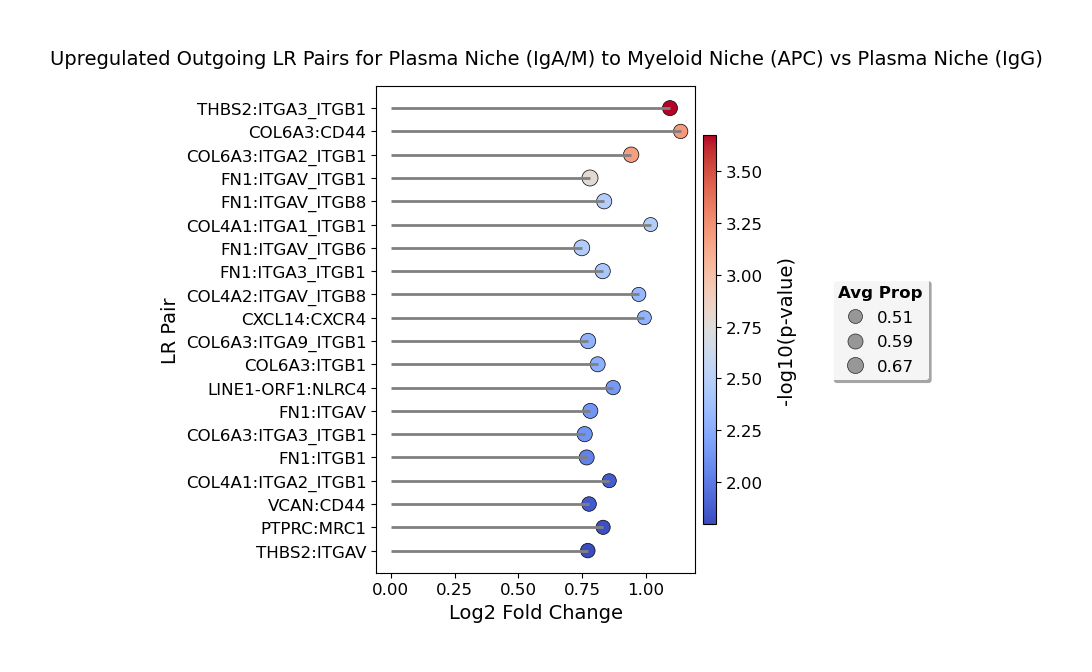

Upregulated outgoing pairs for Plasma Niche (IgA/M) -> Myeloid Niche (APC): 20 interactions | FC range: 0.75-1.14 | Expr range: 0.51-0.67
 Processing neighbor: Myeloid Niche (Pro-tumor)
Significant pairs for outgoing from Plasma Niche (IgA/M) to Myeloid Niche (Pro-tumor) (Plasma Niche (IgA/M) vs Plasma Niche (IgG)): 3
Significant pairs for incoming from Myeloid Niche (Pro-tumor) to Plasma Niche (IgA/M) (Plasma Niche (IgA/M) vs Plasma Niche (IgG)): 231
 Processing neighbor: Neutrophil
Significant pairs for outgoing from Plasma Niche (IgA/M) to Neutrophil (Plasma Niche (IgA/M) vs Plasma Niche (IgG)): 33
Significant pairs for incoming from Neutrophil to Plasma Niche (IgA/M) (Plasma Niche (IgA/M) vs Plasma Niche (IgG)): 222
 Processing neighbor: Pericyte
Significant pairs for outgoing from Plasma Niche (IgA/M) to Pericyte (Plasma Niche (IgA/M) vs Plasma Niche (IgG)): 78
Significant pairs for incoming from Pericyte to Plasma Niche (IgA/M) (Plasma Niche (IgA/M) vs Plasma Niche (IgG)): 42


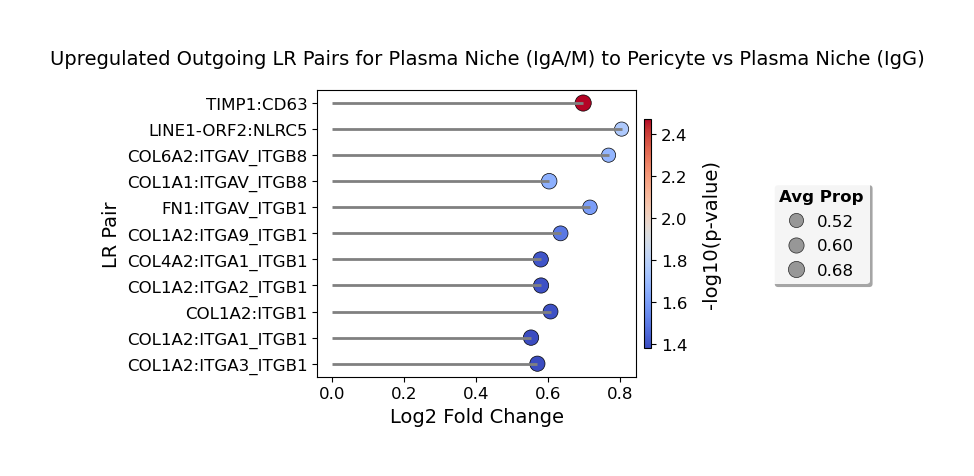

Upregulated outgoing pairs for Plasma Niche (IgA/M) -> Pericyte: 11 interactions | FC range: 0.55-0.80 | Expr range: 0.52-0.68


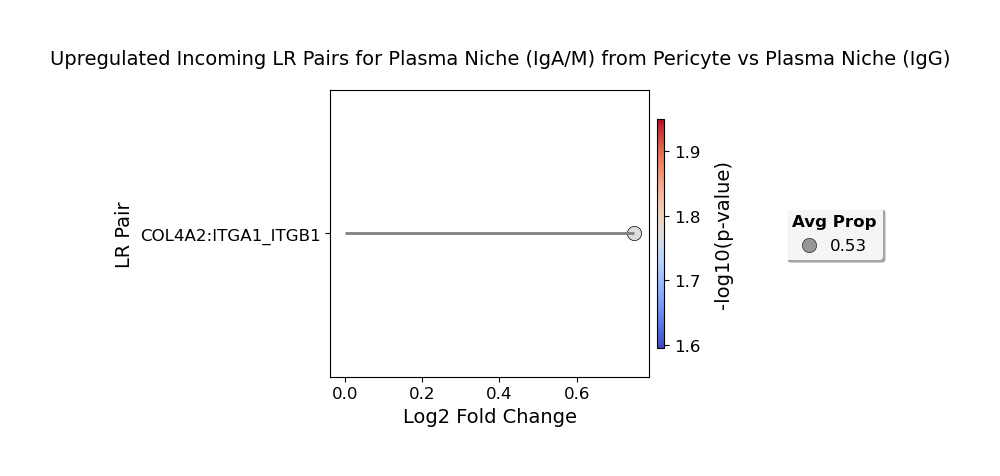

Upregulated incoming pairs for Pericyte -> Plasma Niche (IgA/M): 1 interactions | FC range: 0.75-0.75 | Expr range: 0.53-0.53
 Processing neighbor: Plasma Niche (IgA/M)
Significant pairs for outgoing from Plasma Niche (IgA/M) to Plasma Niche (IgA/M) (Plasma Niche (IgA/M) vs Plasma Niche (IgG)): 502
Significant pairs for incoming from Plasma Niche (IgA/M) to Plasma Niche (IgA/M) (Plasma Niche (IgA/M) vs Plasma Niche (IgG)): 502


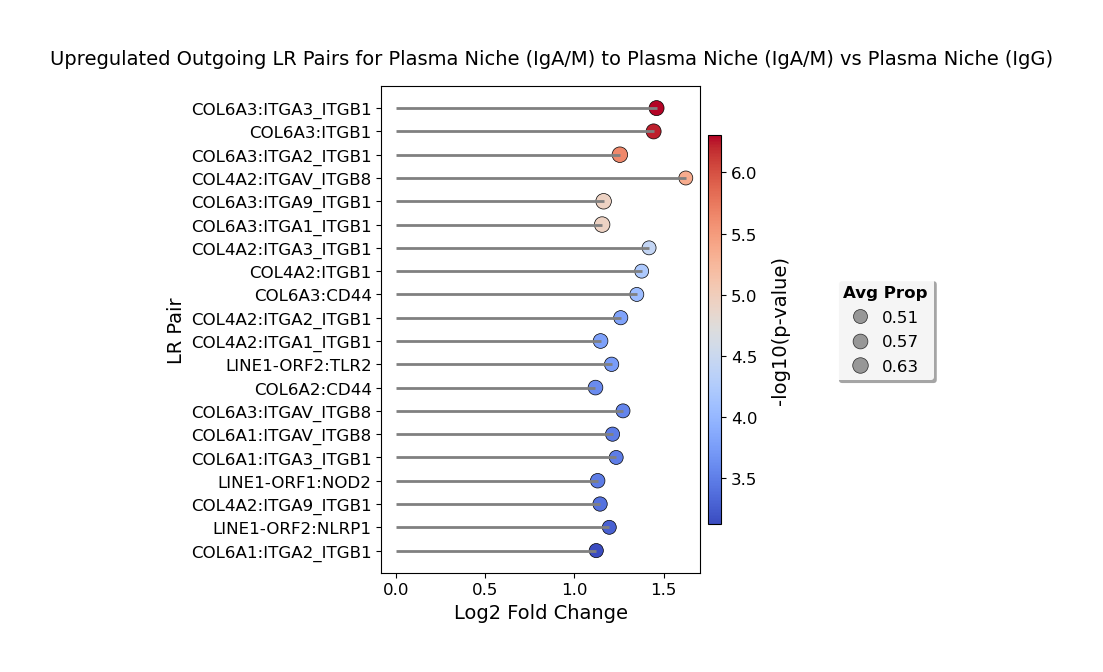

Upregulated outgoing pairs for Plasma Niche (IgA/M) -> Plasma Niche (IgA/M): 20 interactions | FC range: 1.12-1.62 | Expr range: 0.51-0.63


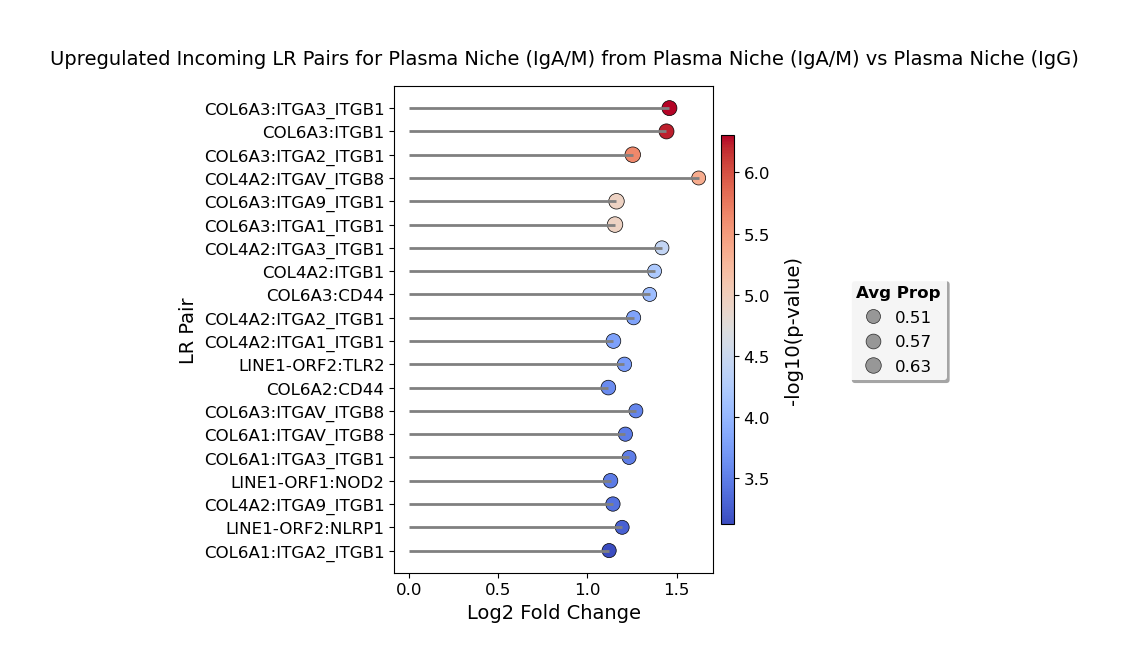

Upregulated incoming pairs for Plasma Niche (IgA/M) -> Plasma Niche (IgA/M): 20 interactions | FC range: 1.12-1.62 | Expr range: 0.51-0.63
 Processing neighbor: Plasma Niche (IgG)
Significant pairs for outgoing from Plasma Niche (IgA/M) to Plasma Niche (IgG) (Plasma Niche (IgA/M) vs Plasma Niche (IgG)): 124
Significant pairs for incoming from Plasma Niche (IgG) to Plasma Niche (IgA/M) (Plasma Niche (IgA/M) vs Plasma Niche (IgG)): 0


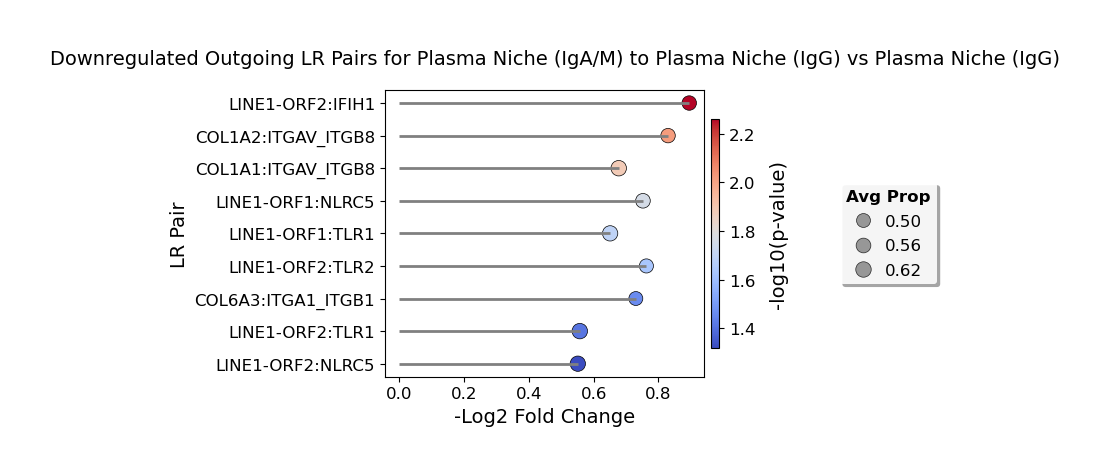

Downregulated outgoing pairs for Plasma Niche (IgA/M) -> Plasma Niche (IgG): 9 interactions | FC range: 0.55-0.90 | Expr range: 0.50-0.62
 Processing neighbor: SMC
Significant pairs for outgoing from Plasma Niche (IgA/M) to SMC (Plasma Niche (IgA/M) vs Plasma Niche (IgG)): 1
Significant pairs for incoming from SMC to Plasma Niche (IgA/M) (Plasma Niche (IgA/M) vs Plasma Niche (IgG)): 222
 Processing neighbor: T/NK
Significant pairs for outgoing from Plasma Niche (IgA/M) to T/NK (Plasma Niche (IgA/M) vs Plasma Niche (IgG)): 254
Significant pairs for incoming from T/NK to Plasma Niche (IgA/M) (Plasma Niche (IgA/M) vs Plasma Niche (IgG)): 115


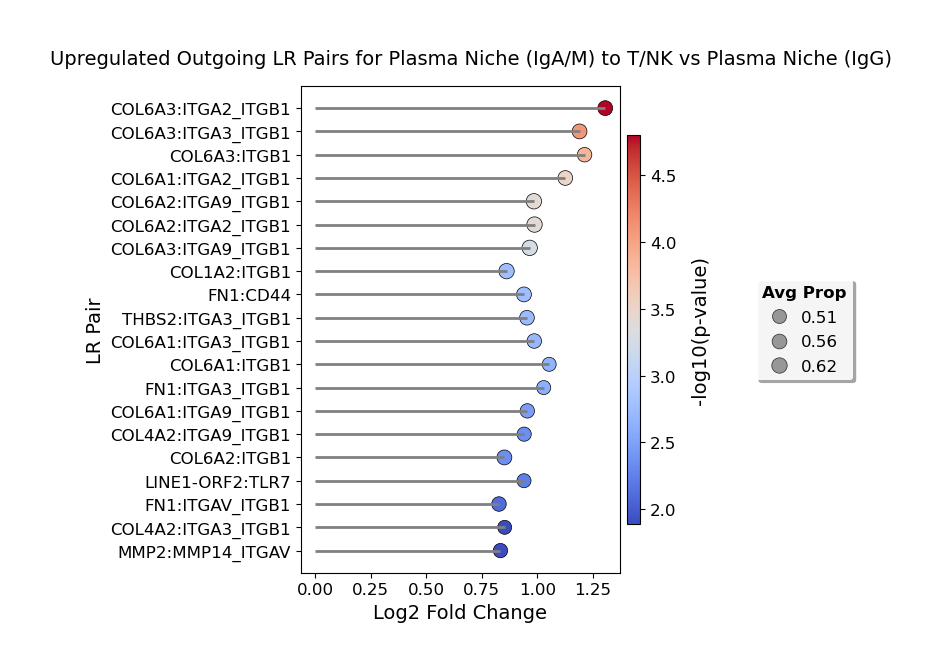

Upregulated outgoing pairs for Plasma Niche (IgA/M) -> T/NK: 20 interactions | FC range: 0.83-1.31 | Expr range: 0.51-0.62


In [27]:
# SCENARIO 1: Cell type comparison
plot_configs = [("Plasma Niche (IgA/M)", "Plasma Niche (IgG)")]
neighbor_types = analyze_cell_type_pairs(
    adata_CCC, plot_configs, cell_type_col='niche4', 
    group_key='patient', exclude_niches=['Plasma cell', 'Myeloid',]
)

# L-R pair analysis for cell type comparison
perform_lr_plotting_cell_types(
    adata_CCC, plot_configs, cell_type_col='niche4', exclude_niches=[],
    neighbor_types=neighbor_types, 
    #selected_neighbors=['CAF', 'Pericyte'], 
    min_neg_log_p=1.3, min_avg_prop=0.5, top_n=20, sort_by='abs_log2_fc'
)